---
title: WGCNA analysis and co-expression clusters mixed models
subtitle: ACE and PSS association with sncRNA co-expression cluster activity
author: Caio Braga
date: last-modified
format:
  html:
    toc: true
    toc-depth: 4
    code-fold: false
    embed-resources: true
---

***Objective:***\
My objective is to investigate whether PSS and ACE are associated with the activity level of sncRNA co-expression clusters, suggesting a specific signature for the coordinated stress response embedded in sperm sncRNA content.

***Analysis:***\
I used the WGCNA analysis to create a co-expression network from a given set of samples, identify its co-expression clusters, and estimate the clusters’ activity.

In this script, the analysis progresses from a specific set of samples, identified through the PSS dynamic analysis, to a more general set covering all available samples. This shift from specific to general sample selection evaluates the co-expression while considering the trade-off between PSS context and statistical power (sample size).

## Analysis

In [2]:
# load library
library(WGCNA)
library(edgeR)
library(variancePartition)
library(lme4)

In [3]:
# load data
df_dynamic = readRDS("data/df_dynamic_DC.RDS")

miRNA_DGE = readRDS("data/DGEList_miRNA_filtered_norm.RDS")
piRNA_DGE = readRDS("data/DGEList_piRNA_filtered_norm.RDS")
tRNA_DGE  = readRDS("data/DGEList_tRNA_filtered_norm.RDS")

dynamic_candidates  = readRDS("data/dynamic_cadidate_all_subjects_DC_DE.RDS")

info = read.csv("data/data_for_modeling.csv",
                row.names = read.csv("data/data_for_modeling.csv")[,1])[,-1]

In [4]:
# get the dynamic sncRNA set after following Morgan's pipeline
dynamic_miRNA = dynamic_candidates$miRNA_DE[(dynamic_candidates$miRNA_DE$dynamic_count_DE >= 7),]$miRNA
dynamic_piRNA = dynamic_candidates$piRNA_DE[(dynamic_candidates$piRNA_DE$dynamic_count_DE >= 7),]$piRNA
dynamic_tRNA = dynamic_candidates$tRNA_DE[(dynamic_candidates$tRNA_DE$dynamic_count_DE >= 7),]$tRNA

sncRNA_DGE = rbind(miRNA_DGE[dynamic_miRNA,rownames(info)],
                   piRNA_DGE[dynamic_piRNA,rownames(info)],
                   tRNA_DGE[dynamic_tRNA,rownames(info)])

In [5]:
# get the dynamic PSS reference visits
increase_dynamic = read.csv("data/mark_increase_dynamic.csv")[,-1]
stability_low_dynamic = read.csv("data/mark_stability_low_dynamic.csv")[,-1]
stability_moderate_dynamic = read.csv("data/mark_stability_moderate_dynamic.csv")[,-1]

# function to get samples from PSS dynamic classification data.frame  
get_samples <- function(mark_df, delay = 0){
    subjects = gsub("50","",mark_df$Record_ID) # remove "50", from the Record_ID
    visit = mark_df$mark+delay
    sample = paste(subjects,"-",visit,sep="") # putting subject and visit together
    return(sample)
}
# identify samples 2 visits after the dynamic
increase_dynamic_2m   = get_samples(increase_dynamic,delay=2)
stable_low_dynamic_2m = get_samples(stability_low_dynamic,delay=2)
stable_mod_dynamic_2m = get_samples(stability_moderate_dynamic,delay=2)

##### Obs. check prior scripts manually defined vectors for PSS dynamic

Just to be transparent: in an old script - `DINGO_WGCNA_analysis.ipynb` _stored on the lab server_ - I manually created the vectors to select samples for each dynamic after consulting the .csv files produced by the sliding window algorithm. Doing this manually was a poor practice and led to some inconsistencies for the low-stress dynamic vector. Creating a trivial function, like the `get_samples()`, would easily prevent this problem. 

In [6]:
stability_low_dynamic

Record_ID,mark
<int>,<int>
50014,2
50016,3
50016,4
50016,6
50016,7
50037,3
50043,4
50068,2
50068,4


In [7]:
# error spotted in a manually written array for stable stress
cat("STABLE LOW STRESS VECTOR\n")
stability_low_dynamic_man = c("014-4","016-5","016-6","016-8","016-9","037-5","043-6",
                              "068-5","068-6","068-7","068-8","072-4","072-5","072-7",
                              "075-6","075-9","086-8","086-5","086-7","086-8","086-9",
                              "112-7","121-4","121-9","121-6","121-7","121-8","121-9")

cat("equal length?",length(stable_low_dynamic_2m) == length(stability_low_dynamic_man),"\n")

cat("equal content?",identical(stable_low_dynamic_2m,stability_low_dynamic_man),"\n")

cat("any duplicated sample?",stability_low_dynamic_man[duplicated(stability_low_dynamic_man)],"\n")

cat("missing sample from the actual low stabel dynamic?",stable_low_dynamic_2m[!(stable_low_dynamic_2m %in% stability_low_dynamic_man)])

STABLE LOW STRESS VECTOR
equal length? TRUE 
equal content? FALSE 
any duplicated sample? 086-8 121-9 
missing sample from the actual low stabel dynamic? 068-4 075-8 086-4 112-4 121-5

In [8]:
cat("STABLE MODERATE STRESS VECTOR\n")
stability_moderate_dynamic_man = c("007-7","007-8","018-5","018-7","019-5","021-4","023-8",
                                   "023-9","025-5","025-6","025-9","046-9","055-4","055-9",
                                   "074-7","074-8","074-9","080-4","088-5","088-8","088-9",
                                   "104-7","104-8","104-9","107-5")
cat("equal content?",identical(stable_mod_dynamic_2m,stability_moderate_dynamic_man),"\n")

STABLE MODERATE STRESS VECTOR
equal content? TRUE 


In [9]:
cat("INCREASE STRESS VECTOR\n")
increase_dynamic_man = c("006-9","007-4","023-5","025-4","042-9","055-8",
                         "084-9","085-8","104-5","107-8")
cat("equal content?",identical(increase_dynamic_2m,increase_dynamic_man),"\n")

INCREASE STRESS VECTOR
equal content? TRUE 


### Create data.frame for analysis

In [10]:
# setting variable type
info$Batch   = as.factor(info$Batch) 
info$Subject = as.factor(info$Subject) 

In [11]:
# selecting samples

# all dynamics
info_all = info[c(increase_dynamic_2m,
                  stable_low_dynamic_2m,
                  stable_mod_dynamic_2m),]
info_all$dynamic  = c(rep("increase",length(increase_dynamic_2m)),
                      rep("stable_low",length(stable_low_dynamic_2m)),
                      rep("stable_mod",length(stable_mod_dynamic_2m)))
info_all$dynamic = as.factor(info_all$dynamic)
# set1: stable low + increase
info_set1 = info[c(increase_dynamic_2m,
                   stable_low_dynamic_2m),]
info_set1$dynamic  = c(rep("increase",length(increase_dynamic_2m)),
                       rep("stable_low",length(stable_low_dynamic_2m)))
info_set1$dynamic = as.factor(info_set1$dynamic)
# set2: stable low + stable moderate
info_set2 = info[c(stable_mod_dynamic_2m,
                   stable_low_dynamic_2m),]
info_set2$dynamic  = c(rep("stable_mod",length(stable_mod_dynamic_2m)),
                       rep("stable_low",length(stable_low_dynamic_2m)))
info_set2$dynamic = as.factor(info_set2$dynamic)

In [12]:
# get voom processed data!
design_matrix = ~ ACE*PSS_2m_prior + (1|Batch) + (1|Subject)
unfiltered_design_matrix = ~ ACE*PSS_2m_prior + (1|Batch) + (1|Subject)

# identifying samples with PSS avaiable two months before!
complete_PSS_2m_samples= rownames(na.omit(info[,c("Sample","PSS_2m_prior")]))

voom_expr_unf = voomWithDreamWeights(counts = sncRNA_DGE[,complete_PSS_2m_samples], 
                                    formula = unfiltered_design_matrix, 
                                    data = info[complete_PSS_2m_samples,], 
                                    lib.size = info[complete_PSS_2m_samples,]$sequence_count)

voom_expr_all = voomWithDreamWeights(counts = sncRNA_DGE[,info_all$Sample], 
                                     formula = design_matrix, 
                                     data = info_all, 
                                     lib.size = info_all$sequence_count)

voom_expr_set1 = voomWithDreamWeights(counts = sncRNA_DGE[,info_set1$Sample], 
                                      formula = design_matrix, 
                                      data = info_set1, 
                                      lib.size = info_set1$sequence_count)

voom_expr_set2 = voomWithDreamWeights(counts = sncRNA_DGE[,info_set2$Sample], 
                                      formula = design_matrix, 
                                      data = info_set2, 
                                      lib.size = info_set2$sequence_count)

Memory usage to store result: >2.4 Mb

Dividing work into 9 chunks...


Total:2 s

Memory usage to store result: >942.3 Kb

Dividing work into 9 chunks...


Total:2 s

Memory usage to store result: >613.6 Kb

Dividing work into 9 chunks...


Total:2 s

Memory usage to store result: >810.8 Kb

Dividing work into 9 chunks...


Total:2 s



### WGCNA

In [13]:
# recommended setup in WGCNA documentation
options(stringsAsFactors = FALSE);
enableWGCNAThreads(nThreads = 12)

# Set of soft-thresholding power to check
powers = c(seq(4,10,by=1), seq(12,20, by=2));

Allowing parallel execution with up to 12 working processes.


In [14]:
removing_species_notation = function(data){
    names_sncRNA = gsub("hsa-","",colnames(data))
    names_sncRNA = gsub("Homo_sapiens_","",names_sncRNA)
    colnames(data) = names_sncRNA
    return(data)
}

#### Set 1: Stable low + Increase

In [15]:
data_for_WGCNA = t(voom_expr_set1$E)
data_for_WGCNA = removing_species_notation(data_for_WGCNA)
cat("Samples:",nrow(data_for_WGCNA))

Samples: 38

In [16]:
powerTables = list(data = pickSoftThreshold(data_for_WGCNA, powerVector=powers,verbose = F)[[2]]);
collectGarbage(); # select 9

   Power SFT.R.sq  slope truncated.R.sq mean.k. median.k. max.k.
1      4    0.360 -0.553          0.542   9.330     8.280  23.40
2      5    0.587 -0.759          0.689   6.650     5.580  19.10
3      6    0.753 -0.832          0.845   5.040     4.050  16.20
4      7    0.775 -0.909          0.795   4.000     3.130  14.20
5      8    0.772 -1.030          0.761   3.290     2.270  12.80
6      9    0.868 -1.080          0.863   2.780     1.810  11.60
7     10    0.831 -1.150          0.785   2.400     1.520  10.70
8     12    0.802 -1.150          0.756   1.870     1.160   9.29
9     14    0.835 -1.130          0.804   1.530     1.010   8.24
10    16    0.846 -1.120          0.819   1.300     0.963   7.41
11    18    0.850 -1.110          0.826   1.130     0.825   6.72
12    20    0.849 -1.130          0.826   0.997     0.679   6.13


 Calculating module eigengenes block-wise from all genes


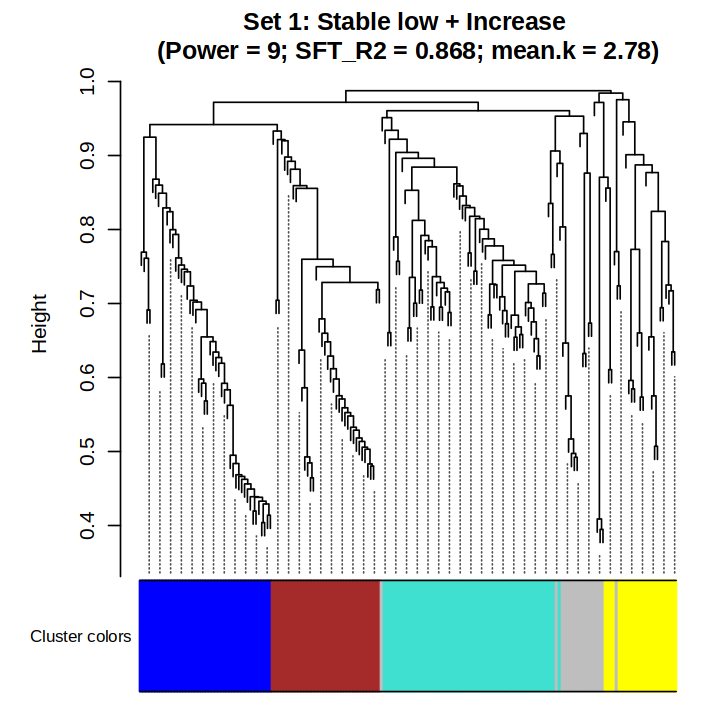

In [17]:
net = blockwiseModules(data_for_WGCNA, power = 9, networkType = "signed",
                        TOMType = "signed", minModuleSize = 19, # minModule = 10% of total
                        reassignThreshold = 0, mergeCutHeight = 0.25,
                        numericLabels = TRUE, pamRespectsDendro = FALSE,
                        verbose = 1)
# Convert labels to colors for plotting
mergedColors = labels2colors(net$colors)
names(mergedColors) = names(net$colors)
# Plot the dendrogram and the module colors underneath
options(repr.plot.width = 6, repr.plot.height = 6)
plotDendroAndColors(net$dendrograms[[1]], mergedColors[net$blockGenes[[1]]],
                    main = "Set 1: Stable low + Increase \n(Power = 9; SFT_R2 = 0.868; mean.k = 2.78)",
                    "Cluster colors",
                    dendroLabels = FALSE, hang = 0.03,
                    addGuide = TRUE, guideHang = 0.05)
# Calculate MEs with color labels
MEs0 = moduleEigengenes(data_for_WGCNA, mergedColors)$eigengenes
MEs = orderMEs(MEs0)
# cluster membership
datKME=signedKME(data_for_WGCNA, MEs, outputColumnName="MM_")
# Get cluster nodes
brown_1 = names(mergedColors[mergedColors == "brown"])
blue_1 = names(mergedColors[mergedColors == "blue"])
turquoise_1 = names(mergedColors[mergedColors == "turquoise"])
yellow_1 = names(mergedColors[mergedColors == "yellow"])

In [18]:
# looking at the top 20 highest cluster membership nodes (kME) within each cluster
library(dplyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [19]:
cat("BLUE\n")
datKME %>% arrange(desc(MM_blue)) %>% rownames() %>% head(,n=20)

BLUE


[1] "piR-720500"  "piR-6305852" "piR-6738734" "piR-3004347" "piR-7025211"
 [6] "piR-2649712" "piR-3416180" "piR-2906214" "piR-765768"  "piR-776281" 
[11] "piR-357703"  "piR-775507"  "piR-4642665" "piR-4957227" "piR-2663764"
[16] "piR-2626556" "piR-7720620" "miR-1247-3p" "piR-2845812" "piR-2958880"

In [20]:
cat("BROWN\n")
datKME %>% arrange(desc(MM_brown)) %>% rownames() %>% head(,n=20)

BROWN


[1] "miR-148a-3p" "miR-200a-3p" "piR-2866828" "miR-26b-5p"  "piR-148659" 
 [6] "piR-155056"  "miR-141-3p"  "piR-383453"  "miR-23b-3p"  "miR-375-3p" 
[11] "piR-167717"  "miR-363-3p"  "miR-429"     "miR-92a-3p"  "let-7a-5p"  
[16] "piR-168697"  "piR-137463"  "piR-73737"   "let-7c-5p"   "piR-187041"

In [21]:
cat("TURQUOISE\n")
datKME %>% arrange(desc(MM_turquoise)) %>% rownames() %>% head(,n=20)

TURQUOISE


[1] "piR-2951599"       "miR-7977"          "piR-2648677"      
 [4] "miR-6765-3p"       "miR-4454"          "piR-2826329"      
 [7] "piR-2866342"       "piR-1248184"       "piR-707596"       
[10] "piR-355426"        "tRNA-Lys-CTT-11-1" "piR-1800335"      
[13] "piR-367314"        "piR-3493222"       "piR-3169149"      
[16] "piR-173953"        "piR-183984"        "piR-2866011"      
[19] "miR-12136"         "miR-1260b"

In [22]:
cat("YELLOW\n")
datKME %>% arrange(desc(MM_yellow)) %>% rownames() %>% head(,n=20)

YELLOW


[1] "piR-12830"   "piR-2866894" "piR-2996788" "piR-7126455" "miR-449a"   
 [6] "miR-34c-5p"  "piR-18"      "piR-17"      "piR-1234402" "piR-769499" 
[11] "piR-270995"  "piR-300977"  "piR-108039"  "miR-4497"    "piR-6475875"
[16] "piR-5955057" "miR-6751-3p" "piR-153778"  "miR-891a-5p" "piR-55506"

In [23]:
# create data.frame for statistical modeling
cluster_data =  data.frame(Subject = info_set1$Subject,
                           Batch = info_set1$Batch,
                           Visit = info_set1$Visit, 
                           PSS_2m_prior = info_set1$PSS_2m_prior,
                           dynamic  = info_set1$dynamic, 
                           ACE = info_set1$ACE,
                           Blue_activity = MEs$MEblue, 
                           Turquoise_activity = MEs$MEturquoise, 
                           Brown_activity = MEs$MEbrown, 
                           Yellow_activity = MEs$MEyellow)
rownames(cluster_data) = rownames(data_for_WGCNA)

##### Blue cluster model

boundary (singular) fit: see help('isSingular')



,Estimate,Std. Error,t value
(Intercept),7.878472e-03,0.076752947,0.102647159
PSS_2m_prior,-5.041608e-04,0.005574118,-0.090446737
ACE,4.006538e-03,0.030708909,0.130468260
PSS_2m_prior:ACE,-4.965538e-06,0.001583095,-0.003136601


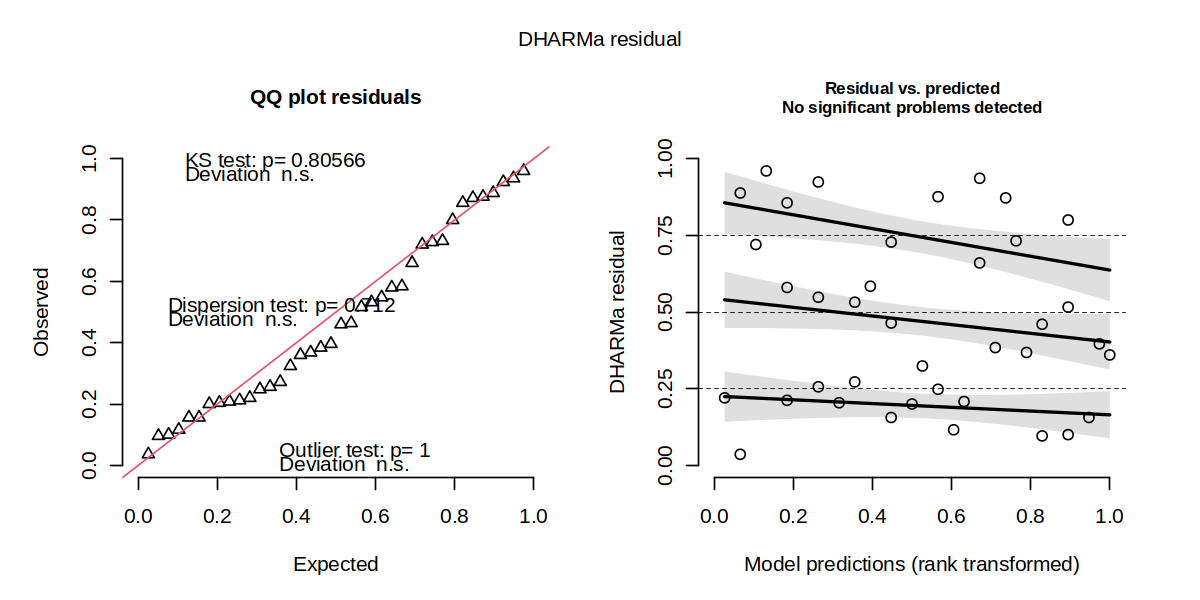

In [24]:
# original model specification (without batch)
model_blue = lmer("Blue_activity ~ PSS_2m_prior + ACE + ACE:PSS_2m_prior + (1|Subject) + (1|Batch)",
                  cluster_data)

options(repr.plot.width = 10, repr.plot.height = 5)
# evaluating residual plot (DHARMa package)
temp = DHARMa::simulateResiduals(fittedModel = model_blue, plot = TRUE)
# checking effects
summary(model_blue)$coefficients # quick look at t-values for promissing significant effect 

# tab_model() function for mixed model result table (sjPlot package)
#options(browser="firefox") # html output 
#sjPlot::tab_model(model_blue, show.re.var = FALSE,digits = 5,p.threshold = c(0.05, 0.01, 0.001))

##### Brown cluster model

,Estimate,Std. Error,t value
(Intercept),-0.0438623435,0.087043348,-0.5039138
PSS_2m_prior,0.0049862707,0.004851097,1.0278645
ACE,0.0065645634,0.029765895,0.2205398
PSS_2m_prior:ACE,-0.0007111392,0.001461999,-0.4864155


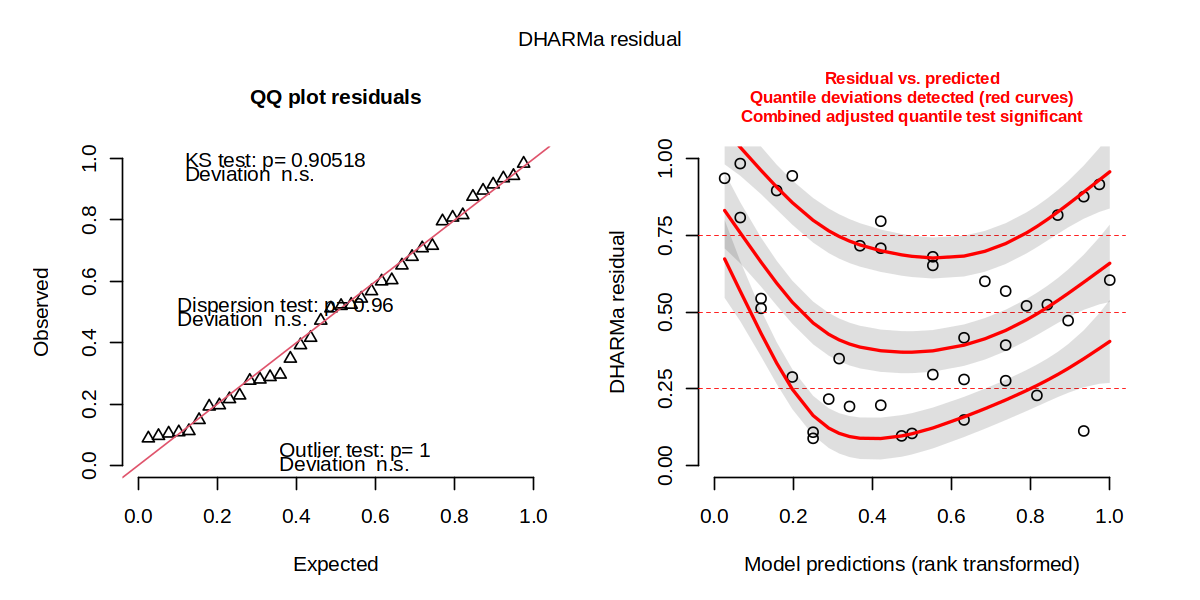

In [25]:
model_brown = lmer("Brown_activity ~ PSS_2m_prior + ACE + ACE:PSS_2m_prior + (1|Subject) + (1|Batch)",
                  cluster_data)
options(repr.plot.width = 10, repr.plot.height = 5)
# evaluating residual plot (DHARMa package)
temp = DHARMa::simulateResiduals(fittedModel = model_brown, plot = TRUE)
# checking effects
summary(model_brown)$coefficients

,Estimate,Std. Error,t value
(Intercept),-0.0265456084,0.0655599746,-0.4049057
I(PSS_2m_prior^2),0.0002594482,0.0001964059,1.3209793
I(ACE^2),0.0012518037,0.0042381085,0.2953685
ACE:PSS_2m_prior,-0.0012008825,0.0017170609,-0.6993826


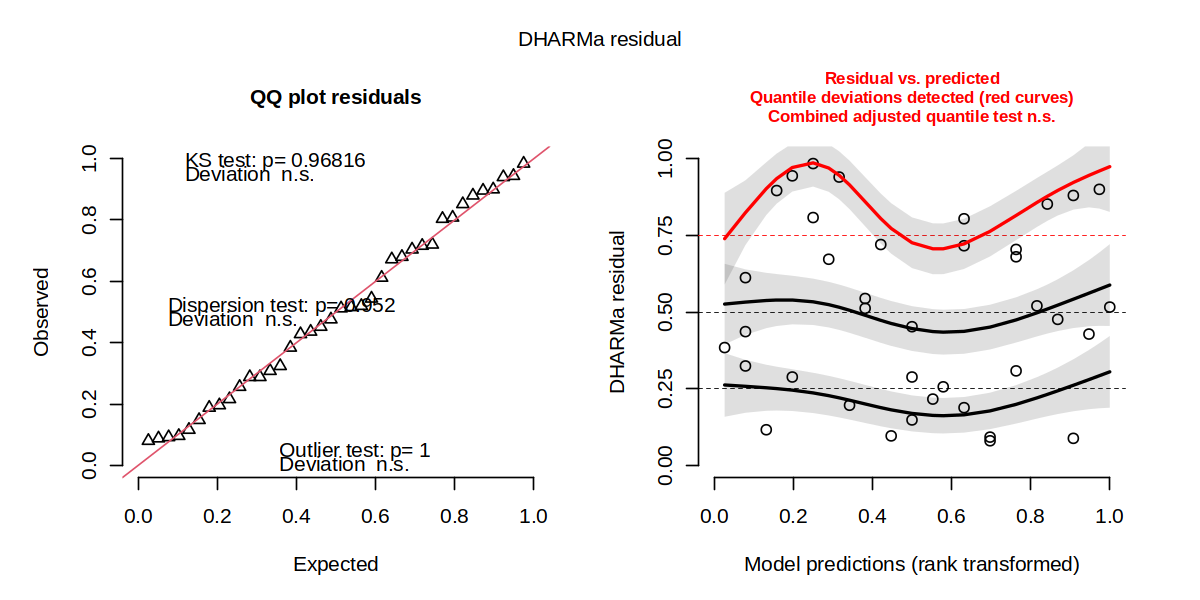

In [26]:
# attempt n.1 to address heteroskedasticity (not perfect, but acceptable)
model_brown_corrected = lmer("Brown_activity ~ I(PSS_2m_prior^2) + I(ACE^2) + ACE:PSS_2m_prior + (1|Subject) + (1|Batch)",
                              cluster_data)
temp = DHARMa::simulateResiduals(fittedModel = model_brown_corrected, plot = TRUE)
summary(model_brown_corrected)$coefficients

##### Turquoise cluster model

,Estimate,Std. Error,t value
(Intercept),-0.0142946063,0.069352041,-0.2061166
PSS_2m_prior,-0.0026603763,0.005575840,-0.4771257
ACE,0.0231906986,0.030195088,0.7680288
PSS_2m_prior:ACE,-0.0001882208,0.001547636,-0.1216182


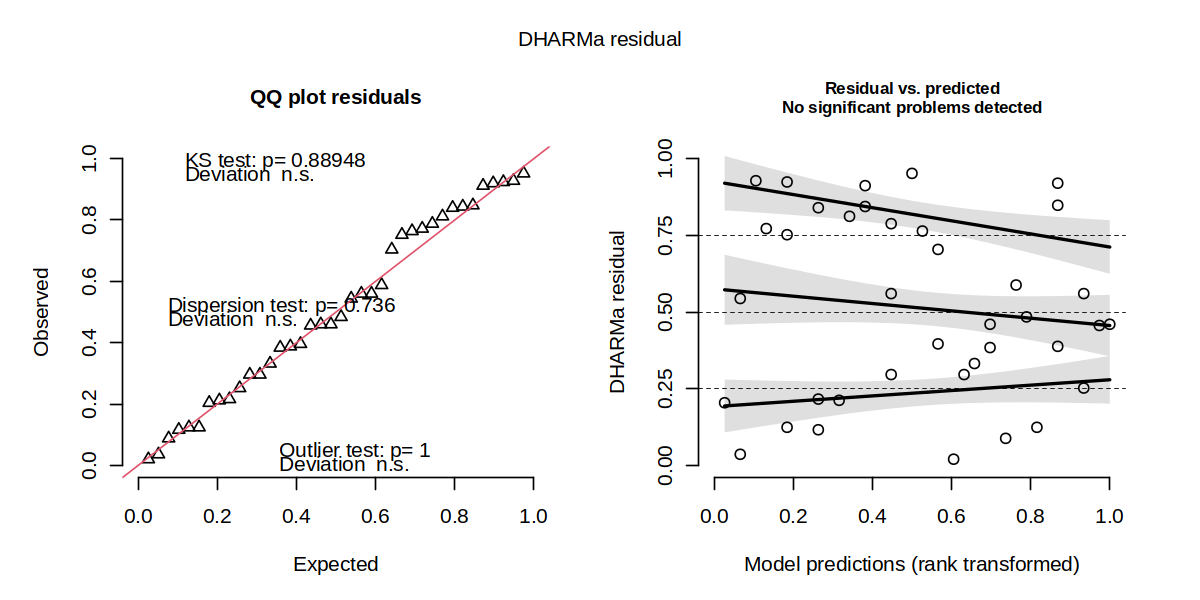

In [27]:
model_turquoise = lmer("Turquoise_activity ~ PSS_2m_prior + ACE + ACE:PSS_2m_prior + (1|Subject) + (1|Batch)",
                  cluster_data)
options(repr.plot.width = 10, repr.plot.height = 5)
temp = DHARMa::simulateResiduals(fittedModel = model_turquoise, plot = TRUE)
# checking effects
summary(model_turquoise)$coefficients

##### Yellow cluster model

boundary (singular) fit: see help('isSingular')



,Estimate,Std. Error,t value
(Intercept),-0.051931949,0.065041835,-0.7984392
PSS_2m_prior,0.005133965,0.005664833,0.9062871
ACE,0.025409203,0.029479433,0.8619298
PSS_2m_prior:ACE,-0.001623204,0.001497125,-1.0842142


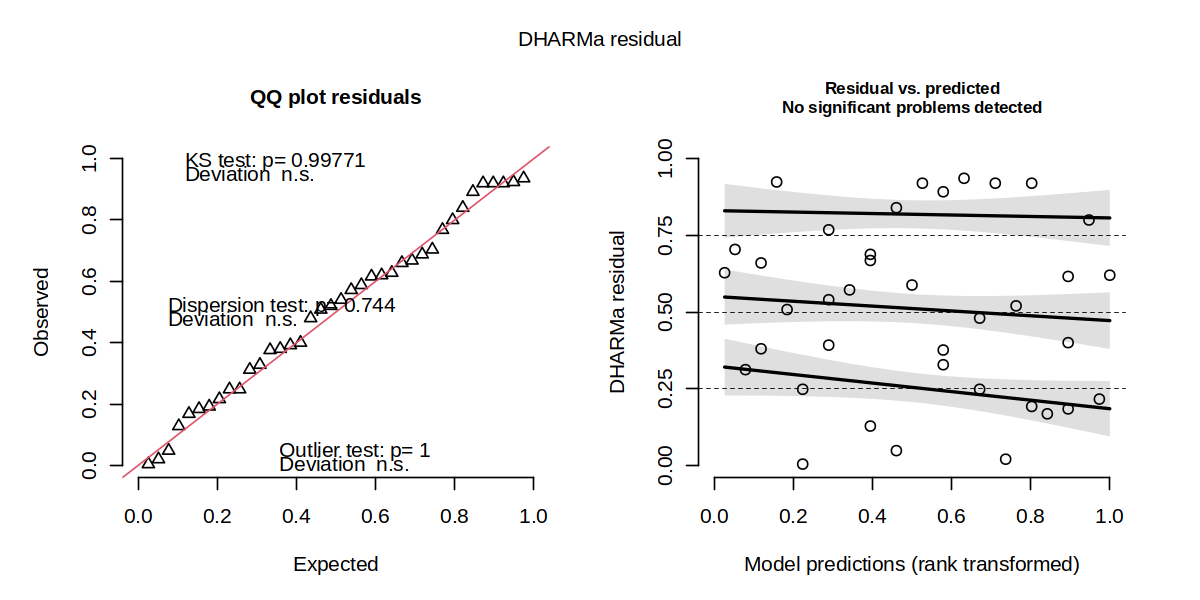

In [28]:
model_yellow = lmer("Yellow_activity ~ PSS_2m_prior + ACE + ACE:PSS_2m_prior + (1|Subject) + (1|Batch)",
                  cluster_data)
options(repr.plot.width = 10, repr.plot.height = 5)
temp = DHARMa::simulateResiduals(fittedModel = model_yellow, plot = TRUE)
# checking effects
summary(model_yellow)$coefficients

#### Set 2: Stable low + Stable moderate

In [29]:
data_for_WGCNA = t(voom_expr_set2$E)
data_for_WGCNA = removing_species_notation(data_for_WGCNA)
cat("Samples:",nrow(data_for_WGCNA))

Samples: 53

In [30]:
powerTables = list(data = pickSoftThreshold(data_for_WGCNA, powerVector=powers,verbose = F)[[2]]);
collectGarbage(); # select 8

   Power SFT.R.sq  slope truncated.R.sq mean.k. median.k. max.k.
1      4    0.629 -0.551          0.584    9.79     8.950  24.80
2      5    0.741 -0.697          0.697    7.16     6.190  20.50
3      6    0.694 -0.800          0.644    5.55     4.310  17.60
4      7    0.623 -0.963          0.569    4.47     3.100  15.60
5      8    0.756 -0.979          0.709    3.72     2.400  14.00
6      9    0.708 -1.070          0.628    3.16     1.940  12.80
7     10    0.633 -1.140          0.529    2.74     1.640  11.80
8     12    0.652 -1.270          0.553    2.15     1.190  10.30
9     14    0.756 -1.180          0.690    1.76     1.020   9.19
10    16    0.720 -1.100          0.640    1.49     1.000   8.31
11    18    0.115 -1.760         -0.120    1.29     0.923   7.58
12    20    0.758 -1.120          0.701    1.14     0.867   6.97


 Calculating module eigengenes block-wise from all genes


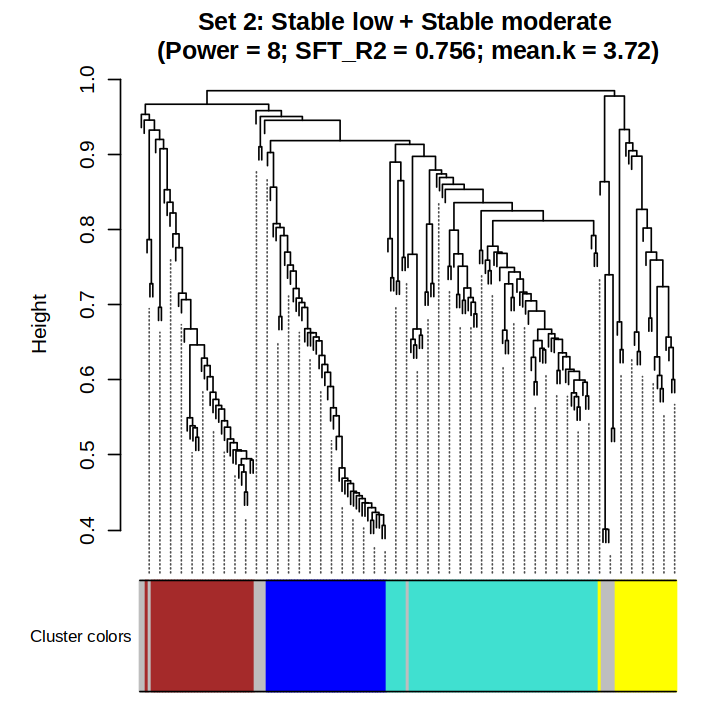

In [31]:
net = blockwiseModules(data_for_WGCNA, power = 8, networkType = "signed",
                        TOMType = "signed", minModuleSize = 19, # minModule = 10% of total
                        reassignThreshold = 0, mergeCutHeight = 0.25,
                        numericLabels = TRUE, pamRespectsDendro = FALSE,
                        verbose = 1)
# Convert labels to colors for plotting
mergedColors = labels2colors(net$colors)
names(mergedColors) = names(net$colors)
# Plot the dendrogram and the module colors underneath
options(repr.plot.width = 6, repr.plot.height = 6)
plotDendroAndColors(net$dendrograms[[1]], mergedColors[net$blockGenes[[1]]],
                    main = "Set 2: Stable low + Stable moderate \n(Power = 8; SFT_R2 = 0.756; mean.k = 3.72)",
                    "Cluster colors",
                    dendroLabels = FALSE, hang = 0.03,
                    addGuide = TRUE, guideHang = 0.05)
# Calculate MEs with color labels
MEs0 = moduleEigengenes(data_for_WGCNA, mergedColors)$eigengenes
MEs = orderMEs(MEs0)
# cluster membership
datKME=signedKME(data_for_WGCNA, MEs, outputColumnName="MM_")
# Get cluster nodes
brown_2 = names(mergedColors[mergedColors == "brown"])
blue_2 = names(mergedColors[mergedColors == "blue"])
turquoise_2 = names(mergedColors[mergedColors == "turquoise"])
yellow_2 = names(mergedColors[mergedColors == "yellow"])

In [32]:
# looking at the top 20 highest cluster membership nodes (kME) within each cluster
cat("BLUE\n")
datKME %>% arrange(desc(MM_blue)) %>% rownames() %>% head(,n=20)

BLUE


[1] "piR-3004347" "piR-720500"  "piR-6305852" "piR-6738734" "piR-7025211"
 [6] "piR-3416180" "piR-2906214" "piR-2663764" "piR-776281"  "piR-765768" 
[11] "piR-2649712" "piR-357703"  "piR-775507"  "piR-4642665" "piR-4957227"
[16] "piR-7720620" "piR-4290678" "miR-1247-3p" "piR-2626556" "piR-2594215"

In [33]:
cat("BROWN\n")
datKME %>% arrange(desc(MM_brown)) %>% rownames() %>% head(,n=20)

BROWN


[1] "miR-148a-3p" "piR-148659"  "miR-26b-5p"  "miR-200a-3p" "piR-2866828"
 [6] "piR-155056"  "miR-141-3p"  "miR-23b-3p"  "miR-375-3p"  "piR-383453" 
[11] "miR-429"     "miR-363-3p"  "piR-167717"  "piR-168697"  "miR-92a-3p" 
[16] "let-7c-5p"   "piR-187041"  "piR-170413"  "miR-320a-3p" "let-7a-5p"

In [34]:
cat("TURQUOISE\n")
datKME %>% arrange(desc(MM_turquoise)) %>% rownames() %>% head(,n=20)

TURQUOISE


[1] "miR-7977"          "miR-6765-3p"       "piR-2951599"      
 [4] "piR-2826329"       "miR-4454"          "piR-1800335"      
 [7] "piR-2742625"       "piR-2717221"       "piR-2866342"      
[10] "piR-707596"        "piR-355426"        "tRNA-Lys-CTT-11-1"
[13] "miR-3907"          "miR-1260b"         "miR-1260a"        
[16] "piR-2648677"       "piR-2680168"       "piR-183984"       
[19] "piR-3169149"       "piR-3493222"

In [35]:
cat("YELLOW\n")
datKME %>% arrange(desc(MM_yellow)) %>% rownames() %>% head(,n=20)

YELLOW


[1] "piR-2866894"       "piR-2996788"       "piR-7126455"      
 [4] "miR-34c-5p"        "miR-449a"          "piR-12830"        
 [7] "piR-270995"        "piR-769499"        "piR-1234402"      
[10] "miR-4497"          "piR-300977"        "piR-108039"       
[13] "piR-18"            "piR-17"            "miR-3614-3p"      
[16] "tRNA-Asn-GTT-12-1" "miR-6751-3p"       "piR-6475875"      
[19] "miR-6826-3p"       "piR-5955057"

In [36]:
# create data.frame for statistical modeling
cluster_data =  data.frame(Subject = info_set2$Subject,
                           Batch = info_set2$Batch,
                           Visit = info_set2$Visit, 
                           PSS_2m_prior = info_set2$PSS_2m_prior,
                           dynamic  = info_set2$dynamic, 
                           ACE = info_set2$ACE,
                           Blue_activity = MEs$MEblue, 
                           Turquoise_activity = MEs$MEturquoise, 
                           Brown_activity = MEs$MEbrown, 
                           Yellow_activity = MEs$MEyellow)
rownames(cluster_data) = rownames(data_for_WGCNA)

##### Blue cluster model

,Estimate,Std. Error,t value
(Intercept),0.0445274972,0.064807425,0.68707401
PSS_2m_prior,-0.0013786212,0.004591083,-0.30028238
ACE,-0.0010202082,0.025499897,-0.04000832
PSS_2m_prior:ACE,-0.0008829695,0.001655031,-0.53350622


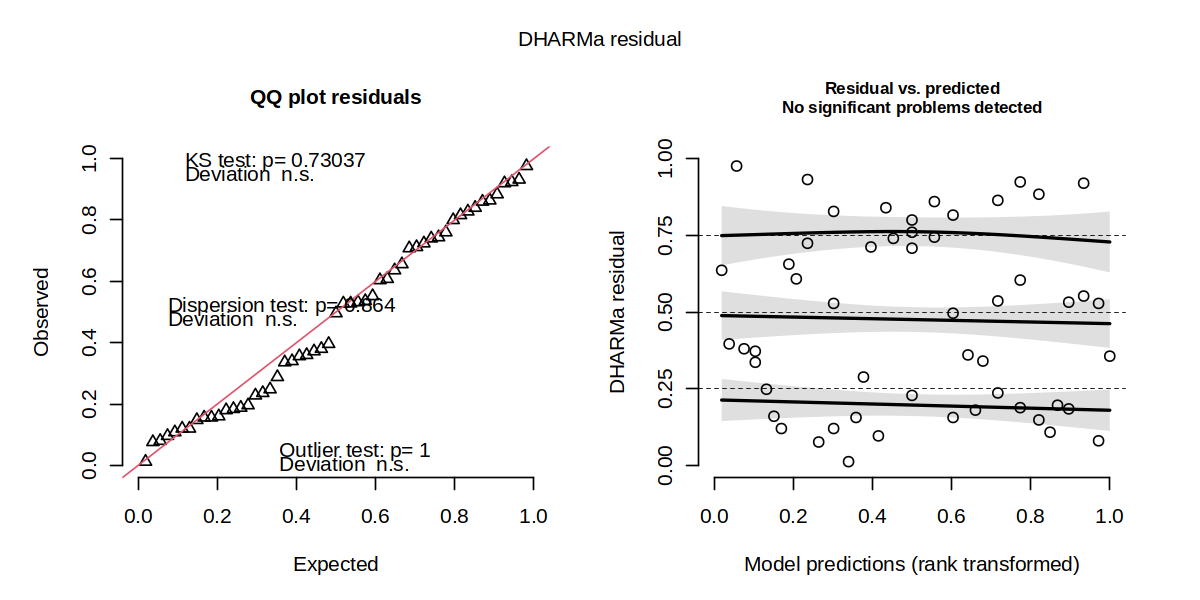

In [37]:
# original model specification (without batch)
model_blue = lmer("Blue_activity ~ PSS_2m_prior + ACE + ACE:PSS_2m_prior + (1|Subject) + (1|Batch)",
                  cluster_data)

options(repr.plot.width = 10, repr.plot.height = 5)
# evaluating residual plot (DHARMa package)
temp = DHARMa::simulateResiduals(fittedModel = model_blue, plot = TRUE)
# checking effects
summary(model_blue)$coefficients # quick look at t-values for promissing significant effect 

# tab_model() function for mixed model result table (sjPlot package)
#options(browser="firefox") # html output 
#sjPlot::tab_model(model_blue, show.re.var = FALSE,digits = 5,p.threshold = c(0.05, 0.01, 0.001))

##### Brown cluster model

,Estimate,Std. Error,t value
(Intercept),-0.0621476817,0.074600514,-0.833073108
PSS_2m_prior,0.0042076119,0.004357733,0.965550687
ACE,-0.0001302072,0.023952860,-0.005435978
PSS_2m_prior:ACE,0.0001223161,0.001574200,0.077700503


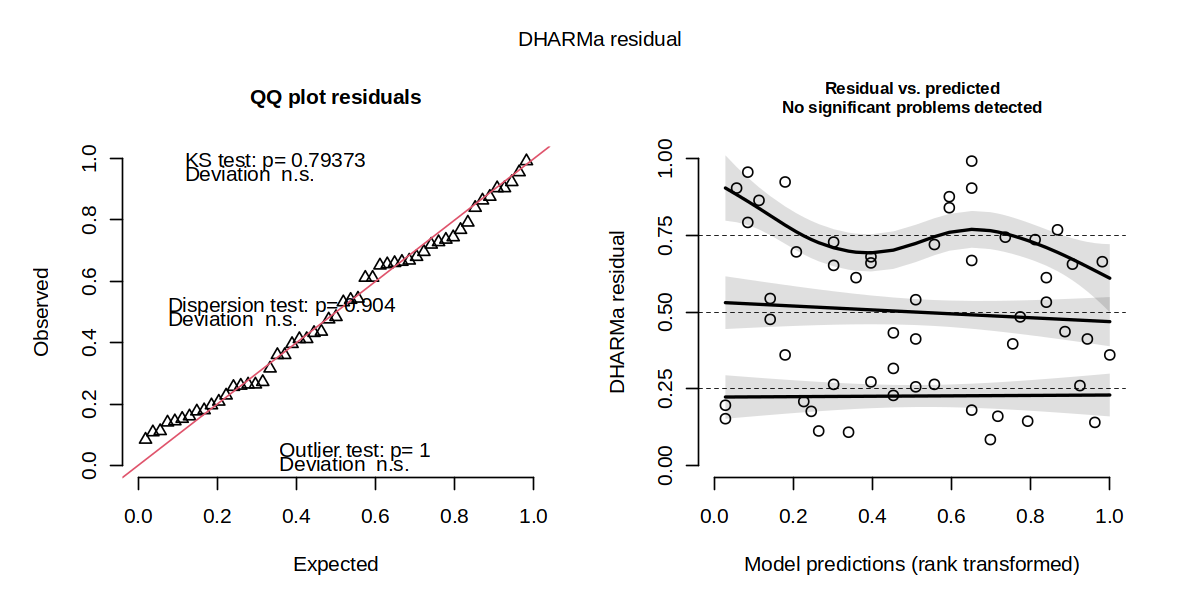

In [38]:
model_brown = lmer("Brown_activity ~ PSS_2m_prior + ACE + ACE:PSS_2m_prior + (1|Subject) + (1|Batch)",
                  cluster_data)
options(repr.plot.width = 10, repr.plot.height = 5)
# evaluating residual plot (DHARMa package)
temp = DHARMa::simulateResiduals(fittedModel = model_brown, plot = TRUE)
# checking effects
summary(model_brown)$coefficients

##### Turquoise cluster model

,Estimate,Std. Error,t value
(Intercept),0.0651373054,0.064610477,1.008153914
PSS_2m_prior,-0.0035650573,0.004639519,-0.768411055
ACE,-0.0001833914,0.025661268,-0.007146623
PSS_2m_prior:ACE,-0.0007016193,0.001667728,-0.420703581


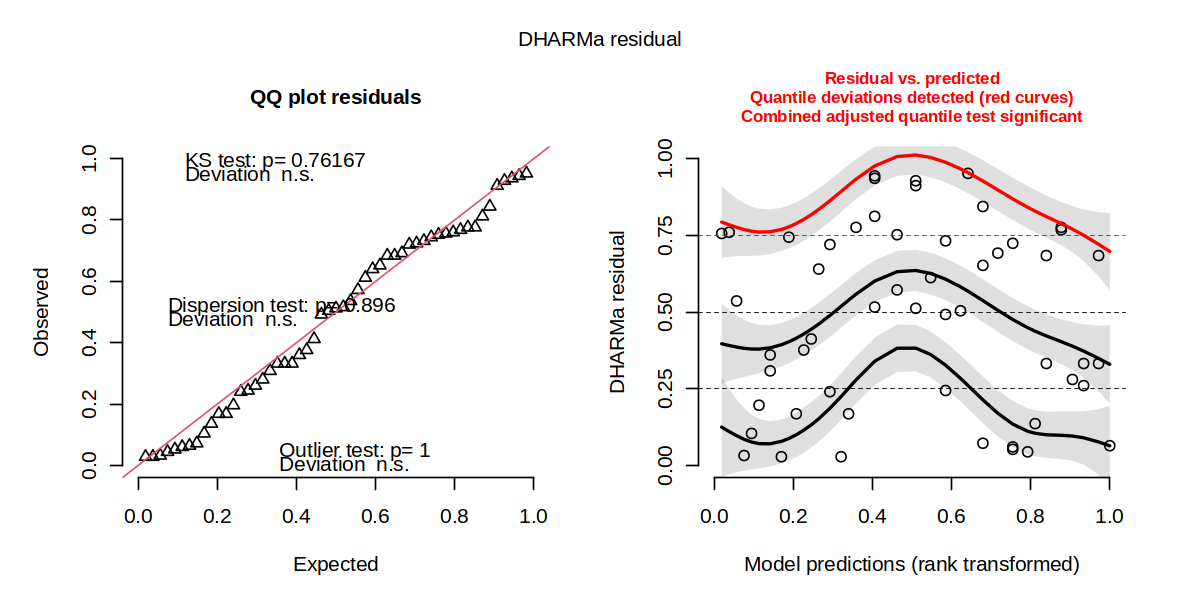

In [39]:
model_turquoise = lmer("Turquoise_activity ~ PSS_2m_prior + ACE + ACE:PSS_2m_prior + (1|Subject) + (1|Batch)",
                  cluster_data)
options(repr.plot.width = 10, repr.plot.height = 5)
# evaluating residual plot (DHARMa package)
temp = DHARMa::simulateResiduals(fittedModel = model_turquoise, plot = TRUE)
# checking effects
summary(model_turquoise)$coefficients

,Estimate,Std. Error,t value
(Intercept),6.058574e-02,0.0399980850,1.514716048
I(PSS_2m_prior^2),-2.341787e-04,0.0001717385,-1.363577388
I(ACE^2),-1.416527e-03,0.0026012010,-0.544566453
ACE:PSS_2m_prior,-6.363793e-06,0.0012431168,-0.005119224


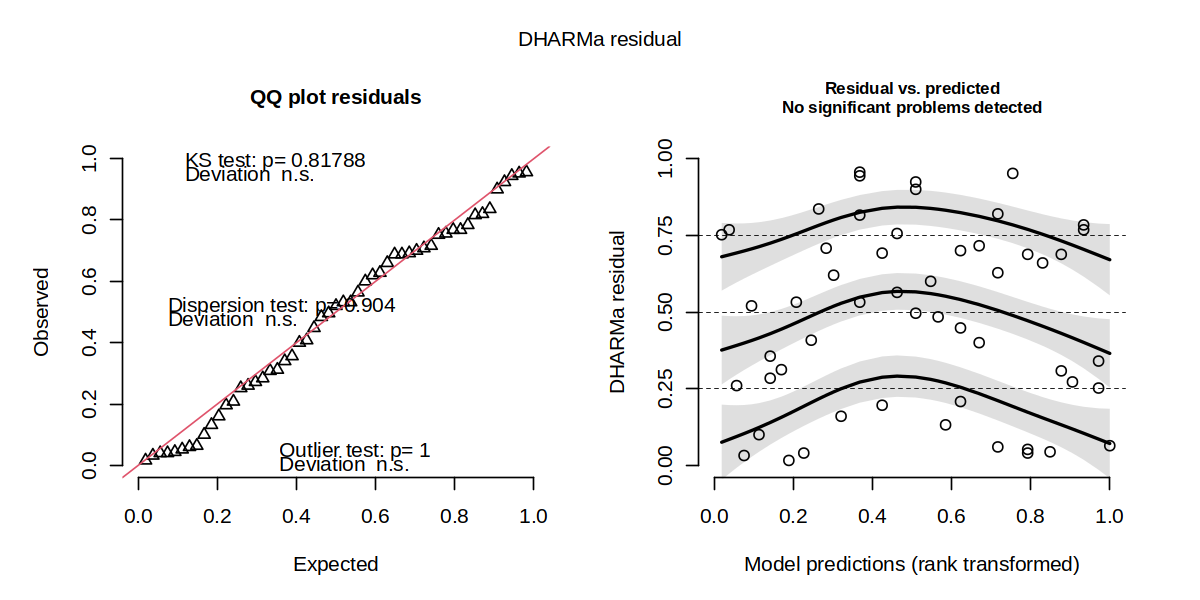

In [40]:
# attempt n.1 to address heteroskedasticity (not perfect, but acceptable)
model_turquoise_corrected = lmer("Turquoise_activity ~ I(PSS_2m_prior^2) + I(ACE^2) + ACE:PSS_2m_prior + (1|Subject) + (1|Batch)",
                  cluster_data)
options(repr.plot.width = 10, repr.plot.height = 5)
# evaluating residual plot (DHARMa package)
temp = DHARMa::simulateResiduals(fittedModel = model_turquoise_corrected, plot = TRUE)
# checking effects
summary(model_turquoise_corrected)$coefficients

#sjPlot::tab_model(model_turquoise_corrected, show.re.var = FALSE,digits = 5,p.threshold = c(0.05, 0.01, 0.001))

##### Yellow cluster model

boundary (singular) fit: see help('isSingular')



,Estimate,Std. Error,t value
(Intercept),-0.0579893880,0.047098294,-1.23124181
PSS_2m_prior,0.0027998848,0.003811149,0.73465635
ACE,0.0015434186,0.021488826,0.07182424
PSS_2m_prior:ACE,0.0009752215,0.001361654,0.71620389


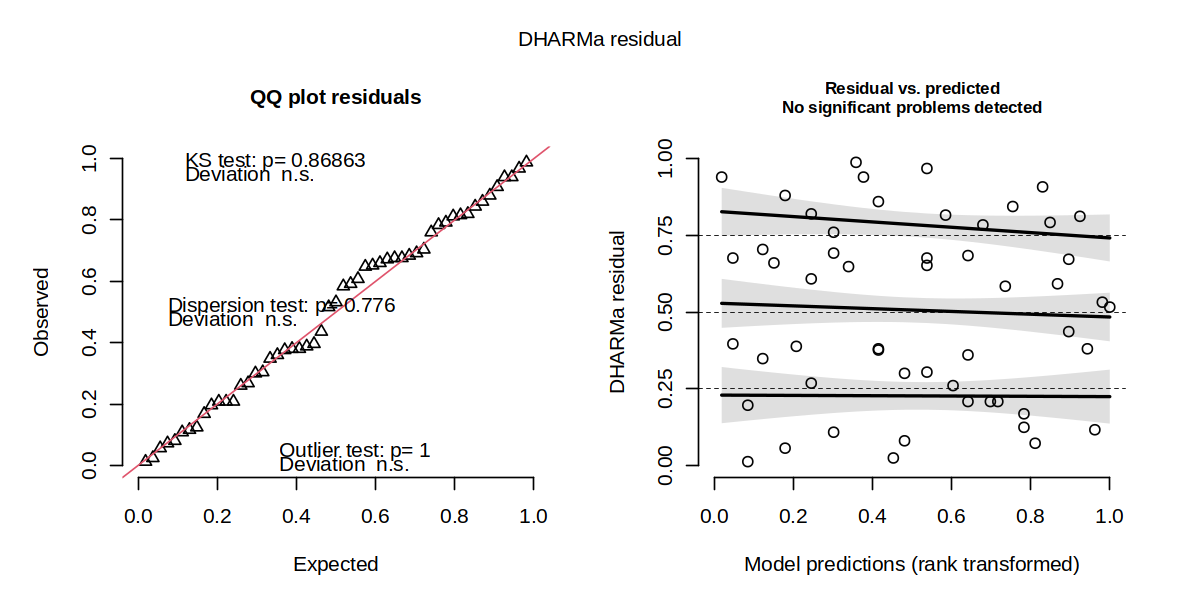

In [41]:
model_yellow = lmer("Yellow_activity ~ PSS_2m_prior + ACE + ACE:PSS_2m_prior + (1|Subject) + (1|Batch)",
                  cluster_data)
options(repr.plot.width = 10, repr.plot.height = 5)
# evaluating residual plot (DHARMa package)
temp = DHARMa::simulateResiduals(fittedModel = model_yellow, plot = TRUE)
# checking effects
summary(model_yellow)$coefficients

#### All: Stable low + Stable moderate + Increase

In [42]:
# Set 1 and Set 2 identified comparable co-expression communities...
# why not pool them together

In [43]:
data_for_WGCNA = t(voom_expr_all$E)
data_for_WGCNA = removing_species_notation(data_for_WGCNA)
cat("Samples:",nrow(data_for_WGCNA))

Samples: 63

In [44]:
powerTables = list(data = pickSoftThreshold(data_for_WGCNA, powerVector=powers,verbose = F)[[2]]);
collectGarbage(); # select 8

   Power SFT.R.sq  slope truncated.R.sq mean.k. median.k. max.k.
1      4    0.552 -0.651          0.494    9.86     8.890  26.20
2      5    0.725 -0.749          0.690    7.18     5.860  21.50
3      6    0.761 -0.854          0.729    5.53     4.160  18.30
4      7    0.746 -0.942          0.702    4.44     2.950  16.10
5      8    0.757 -1.000          0.714    3.68     2.430  14.40
6      9    0.127 -2.240         -0.121    3.12     1.990  13.10
7     10    0.735 -1.190          0.662    2.70     1.660  12.10
8     12    0.672 -1.270          0.583    2.12     1.220  10.50
9     14    0.785 -1.190          0.724    1.74     1.010   9.41
10    16    0.664 -1.220          0.571    1.47     0.964   8.52
11    18    0.652 -1.220          0.554    1.28     0.882   7.81
12    20    0.718 -1.180          0.639    1.13     0.849   7.20


 Calculating module eigengenes block-wise from all genes


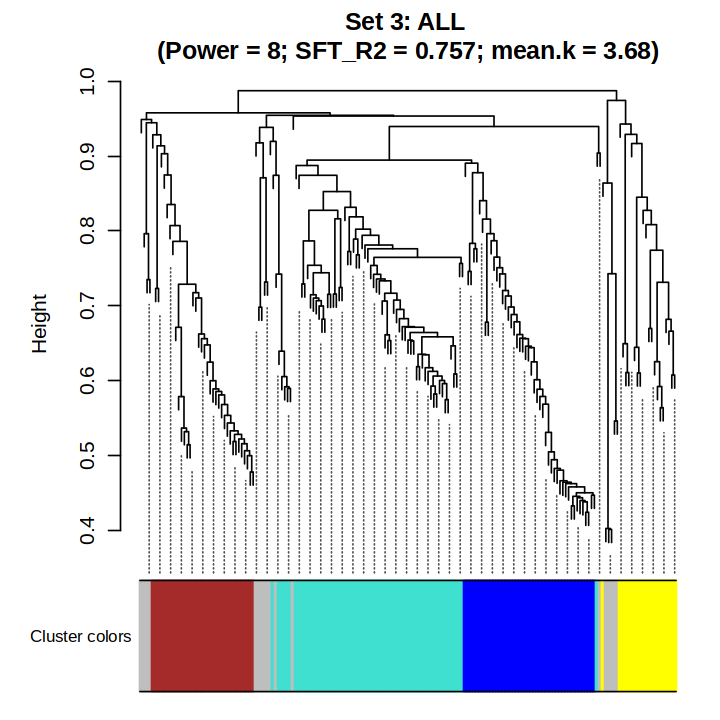

In [45]:
net = blockwiseModules(data_for_WGCNA, power = 8, networkType = "signed",
                        TOMType = "signed", minModuleSize = 19, # minModule = 10% of total
                        reassignThreshold = 0, mergeCutHeight = 0.25,
                        numericLabels = TRUE, pamRespectsDendro = FALSE,
                        verbose = 1)
# Convert labels to colors for plotting
mergedColors = labels2colors(net$colors)
names(mergedColors) = names(net$colors)
# Plot the dendrogram and the module colors underneath
options(repr.plot.width = 6, repr.plot.height = 6)
plotDendroAndColors(net$dendrograms[[1]], mergedColors[net$blockGenes[[1]]],
                    main = "Set 3: ALL \n(Power = 8; SFT_R2 = 0.757; mean.k = 3.68)",
                    "Cluster colors",
                    dendroLabels = FALSE, hang = 0.03,
                    addGuide = TRUE, guideHang = 0.05)
# Calculate MEs with color labels
MEs0 = moduleEigengenes(data_for_WGCNA, mergedColors)$eigengenes
MEs = orderMEs(MEs0)
# cluster membership
datKME=signedKME(data_for_WGCNA, MEs, outputColumnName="MM_")
# Get cluster nodes
brown_3 = names(mergedColors[mergedColors == "brown"])
blue_3 = names(mergedColors[mergedColors == "blue"])
turquoise_3 = names(mergedColors[mergedColors == "turquoise"])
yellow_3 = names(mergedColors[mergedColors == "yellow"])

In [46]:
# looking at the top 20 highest cluster membership nodes (kME) within each cluster
cat("BLUE\n")
datKME %>% arrange(desc(MM_blue)) %>% rownames() %>% head(,n=20)

BLUE


[1] "piR-3004347" "piR-720500"  "piR-6305852" "piR-6738734" "piR-7025211"
 [6] "piR-3416180" "piR-2906214" "piR-776281"  "piR-765768"  "piR-2649712"
[11] "piR-357703"  "piR-775507"  "piR-2663764" "piR-4957227" "piR-4642665"
[16] "piR-2626556" "miR-1247-3p" "piR-7720620" "piR-2859990" "piR-4290678"

In [47]:
cat("BROWN\n")
datKME %>% arrange(desc(MM_brown)) %>% rownames() %>% head(,n=20)

BROWN


[1] "miR-148a-3p" "piR-148659"  "miR-200a-3p" "miR-26b-5p"  "piR-2866828"
 [6] "piR-155056"  "miR-141-3p"  "miR-23b-3p"  "miR-375-3p"  "piR-383453" 
[11] "miR-363-3p"  "miR-429"     "piR-167717"  "miR-92a-3p"  "piR-168697" 
[16] "let-7c-5p"   "let-7a-5p"   "piR-137463"  "piR-73737"   "piR-187041"

In [48]:
cat("TURQUOISE\n")
datKME %>% arrange(desc(MM_turquoise)) %>% rownames() %>% head(,n=20)

TURQUOISE


[1] "miR-7977"          "piR-2951599"       "miR-6765-3p"      
 [4] "piR-2826329"       "miR-4454"          "piR-2866342"      
 [7] "tRNA-Lys-CTT-11-1" "piR-2742625"       "piR-2717221"      
[10] "piR-1800335"       "piR-707596"        "piR-355426"       
[13] "miR-1260a"         "miR-1260b"         "piR-2680168"      
[16] "piR-183984"        "piR-3169149"       "piR-3493222"      
[19] "piR-2648677"       "piR-2866011"

In [49]:
cat("YELLOW\n")
datKME %>% arrange(desc(MM_yellow)) %>% rownames() %>% head(,n=20)

YELLOW


[1] "piR-2866894"       "piR-2996788"       "piR-7126455"      
 [4] "miR-34c-5p"        "miR-449a"          "piR-270995"       
 [7] "piR-12830"         "piR-1234402"       "piR-769499"       
[10] "piR-300977"        "piR-108039"        "piR-18"           
[13] "miR-4497"          "piR-17"            "miR-3614-3p"      
[16] "piR-6475875"       "piR-5955057"       "miR-6751-3p"      
[19] "tRNA-Asn-GTT-12-1" "miR-891a-5p"

In [50]:
# create data.frame for statistical modeling
cluster_data =  data.frame(Subject = info_all$Subject,
                           Batch = info_all$Batch,
                           Visit = info_all$Visit, 
                           PSS_2m_prior = info_all$PSS_2m_prior,
                           dynamic  = info_all$dynamic, 
                           ACE = info_all$ACE,
                           Blue_activity = MEs$MEblue, 
                           Turquoise_activity = MEs$MEturquoise, 
                           Brown_activity = MEs$MEbrown, 
                           Yellow_activity = MEs$MEyellow)
rownames(cluster_data) = rownames(data_for_WGCNA)

##### Blue cluster model

,Estimate,Std. Error,t value
(Intercept),0.059391109,0.058094146,1.0223252
PSS_2m_prior,-0.003297838,0.003611207,-0.9132233
ACE,-0.024951276,0.017787900,-1.4027106
PSS_2m_prior:ACE,0.001030672,0.000993414,1.0375048


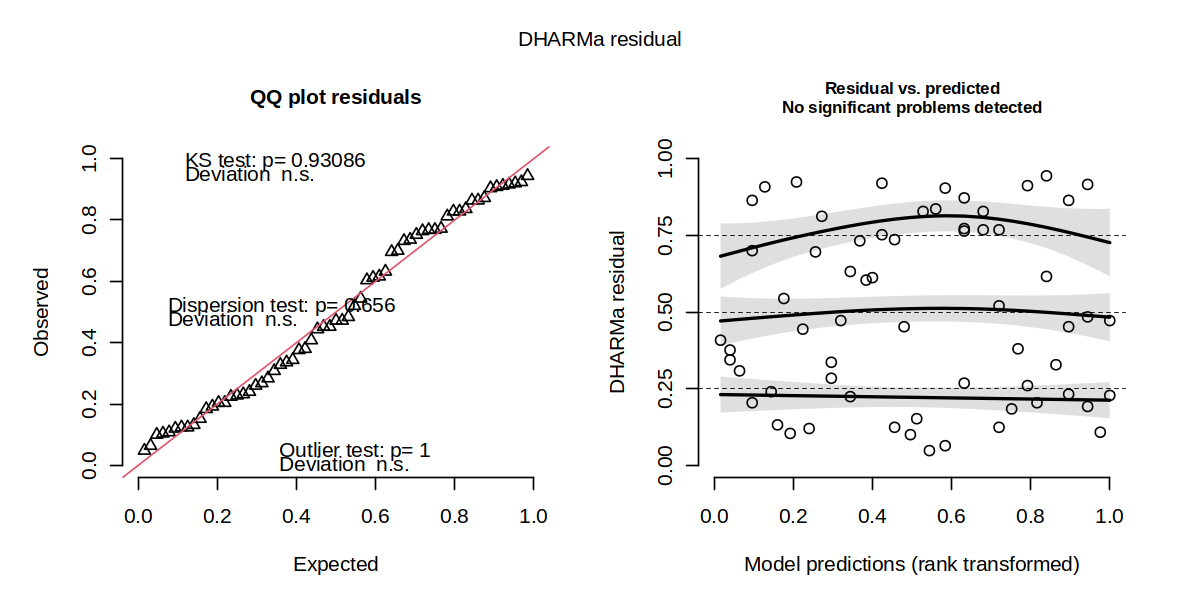

In [51]:
model_blue = lmer("Blue_activity ~ PSS_2m_prior + ACE + ACE:PSS_2m_prior + (1|Subject) + (1|Batch)",
                  cluster_data)
options(repr.plot.width = 10, repr.plot.height = 5)
# evaluating residual plot (DHARMa package)
temp = DHARMa::simulateResiduals(fittedModel = model_blue, plot = TRUE)
# checking effects
summary(model_blue)$coefficients

#sjPlot::tab_model(model_blue, show.re.var = FALSE,digits = 5,p.threshold = c(0.05, 0.01, 0.001))

##### Brown cluster model

,Estimate,Std. Error,t value
(Intercept),-0.0621171695,0.0617318292,-1.0062422
PSS_2m_prior,0.0034374883,0.0030264551,1.1358134
ACE,0.0116550022,0.0130231584,0.8949444
PSS_2m_prior:ACE,-0.0006339118,0.0007219686,-0.8780324


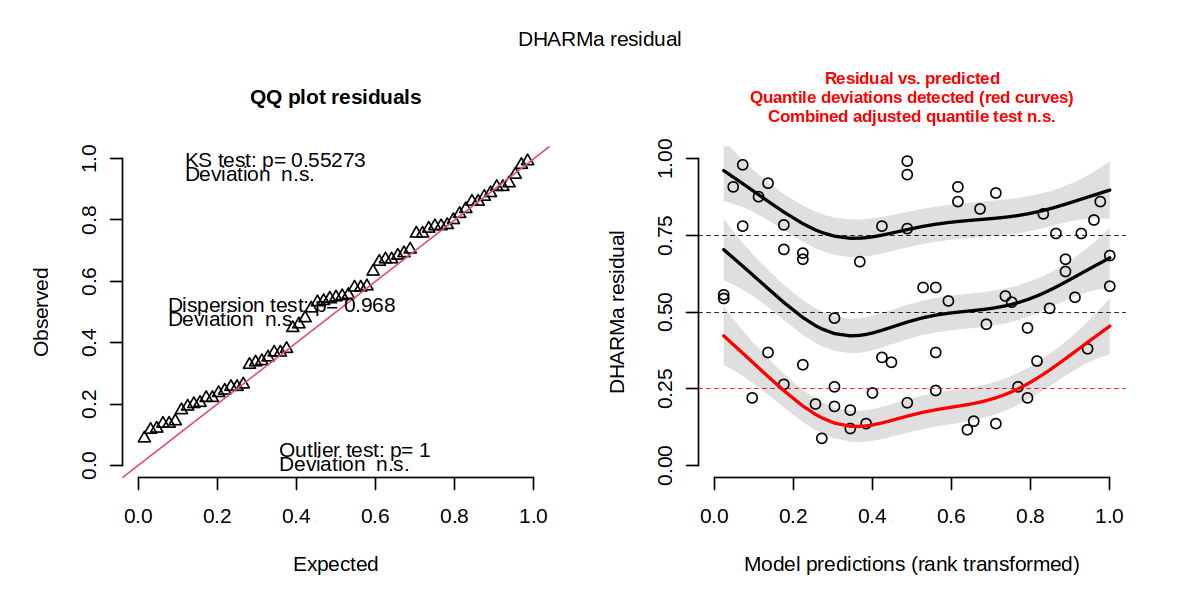

In [52]:
model_brown = lmer("Brown_activity ~ PSS_2m_prior + ACE + ACE:PSS_2m_prior + (1|Subject) + (1|Batch)",
                  cluster_data)
options(repr.plot.width = 10, repr.plot.height = 5)
# evaluating residual plot (DHARMa package)
temp = DHARMa::simulateResiduals(fittedModel = model_brown, plot = TRUE)
# checking effects
summary(model_brown)$coefficients

,Estimate,Std. Error,t value
(Intercept),-0.0358875499,0.0508906774,-0.7051891
I(PSS_2m_prior^2),0.0001362645,0.0001130532,1.2053131
I(ACE^2),0.0016255105,0.0018181071,0.8940675
ACE:PSS_2m_prior,-0.0007600657,0.0008135494,-0.9342589


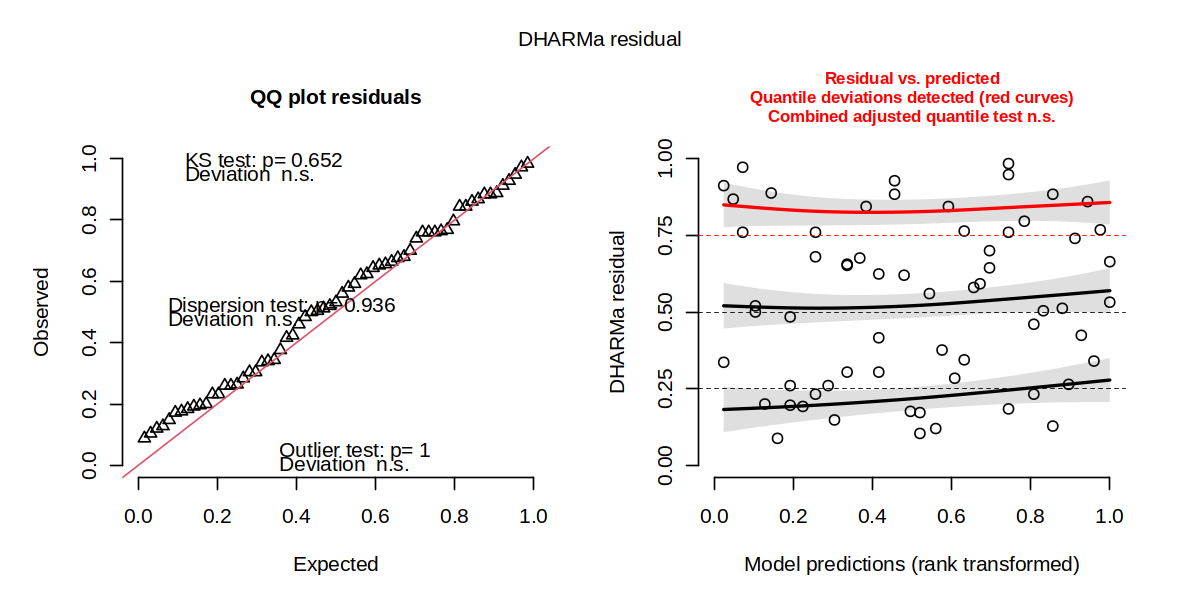

In [53]:
# attempt n.1 to address heteroskedasticity (not perfect, but acceptable)
model_brown_corrected = lmer("Brown_activity ~ I(PSS_2m_prior^2) + I(ACE^2) + ACE:PSS_2m_prior + (1|Subject) + (1|Batch)",
                  cluster_data)
options(repr.plot.width = 10, repr.plot.height = 5)
# evaluating residual plot (DHARMa package)
temp = DHARMa::simulateResiduals(fittedModel = model_brown_corrected, plot = TRUE)
# checking effects
summary(model_brown_corrected)$coefficients

#sjPlot::tab_model(model_blue, show.re.var = FALSE,digits = 5,p.threshold = c(0.05, 0.01, 0.001))

##### Turquoise cluster model

,Estimate,Std. Error,t value
(Intercept),0.085953802,0.061299703,1.402190
PSS_2m_prior,-0.005771902,0.003982183,-1.449432
ACE,-0.030759887,0.018188984,-1.691127
PSS_2m_prior:ACE,0.001697248,0.001001749,1.694285


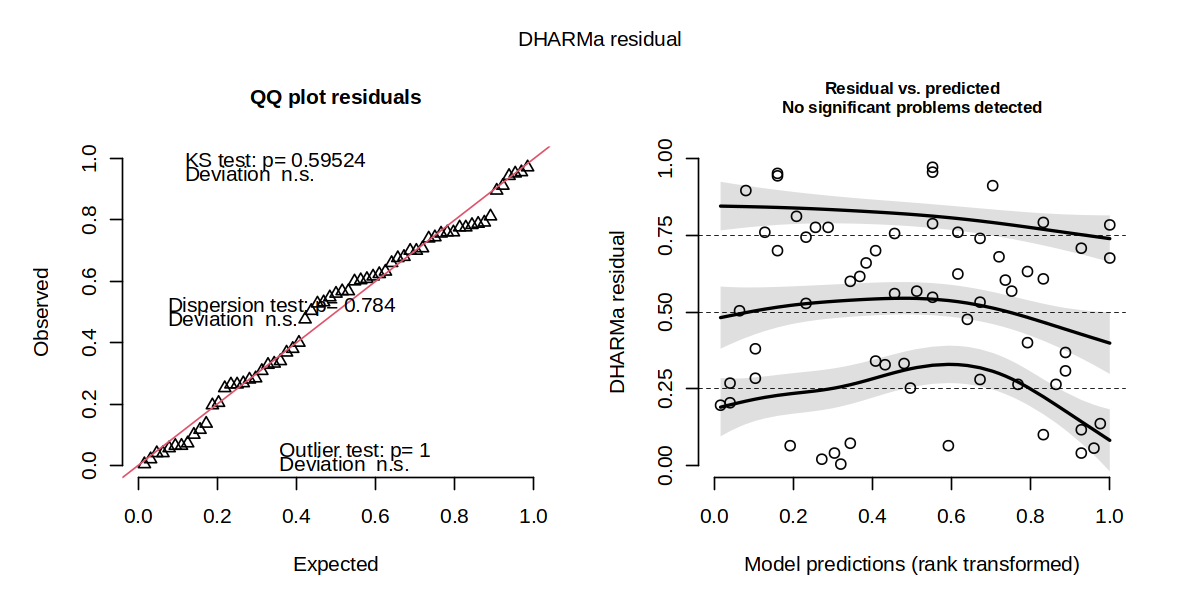

In [54]:
model_turquoise = lmer("Turquoise_activity ~ PSS_2m_prior + ACE + ACE:PSS_2m_prior + (1|Subject) + (1|Batch)",
                  cluster_data)
options(repr.plot.width = 10, repr.plot.height = 5)
# evaluating residual plot (DHARMa package)
temp = DHARMa::simulateResiduals(fittedModel = model_turquoise, plot = TRUE)
# checking effects
summary(model_turquoise)$coefficients

##### Yellow cluster model

boundary (singular) fit: see help('isSingular')



,Estimate,Std. Error,t value
(Intercept),-0.086366578,0.054093732,-1.596610
PSS_2m_prior,0.005148416,0.003857834,1.334535
ACE,0.039002290,0.019870175,1.962856
PSS_2m_prior:ACE,-0.001683122,0.001064133,-1.581684


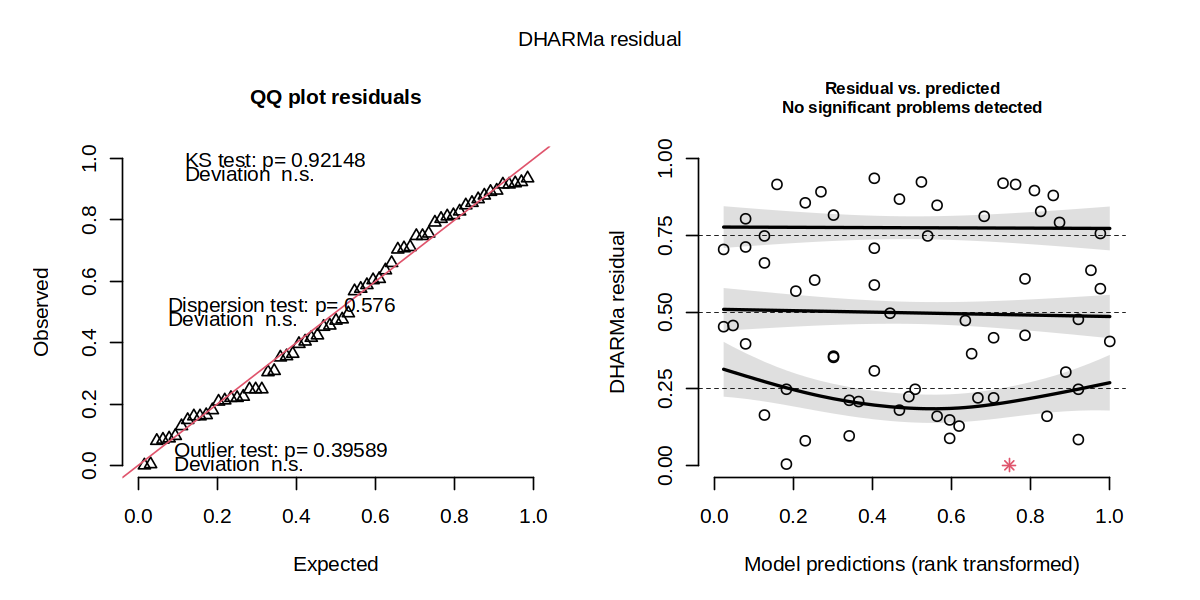

In [55]:
model_yellow = lmer("Yellow_activity ~ PSS_2m_prior + ACE + ACE:PSS_2m_prior + (1|Subject) + (1|Batch)",
                  cluster_data)
options(repr.plot.width = 10, repr.plot.height = 5)
# evaluating residual plot (DHARMa package)
temp = DHARMa::simulateResiduals(fittedModel = model_yellow, plot = TRUE)
# checking effects
summary(model_yellow)$coefficients # ACE p=0.055 (but need to be aware of multiple testing!)

#sjPlot::tab_model(model_yellow, show.re.var = FALSE,digits = 5,p.threshold = c(0.05, 0.01, 0.001))

#### Unfiltered WGCNA

In [56]:
data_for_WGCNA = t(voom_expr_unf$E)
data_for_WGCNA = removing_species_notation(data_for_WGCNA)
cat("Samples:",nrow(data_for_WGCNA))

Samples: 175

In [57]:
powerTables = list(data = pickSoftThreshold(data_for_WGCNA, powerVector=powers,verbose = F)[[2]]);
collectGarbage(); # select 6

   Power SFT.R.sq  slope truncated.R.sq mean.k. median.k. max.k.
1      4   0.5760 -0.461         0.6240   10.60     9.340  26.70
2      5   0.7750 -0.640         0.8030    7.69     6.510  21.90
3      6   0.8150 -0.752         0.8290    5.93     4.730  18.60
4      7   0.7320 -0.829         0.6950    4.76     3.400  16.30
5      8   0.1430 -2.360        -0.0789    3.94     2.650  14.60
6      9   0.1530 -2.390        -0.0625    3.34     2.270  13.30
7     10   0.1680 -2.520        -0.0455    2.89     1.870  12.20
8     12   0.1340 -2.170        -0.1120    2.25     1.340  10.60
9     14   0.1410 -2.120        -0.1040    1.84     1.130   9.48
10    16   0.1150 -1.880        -0.1110    1.55     1.010   8.59
11    18   0.1150 -1.890        -0.1030    1.34     0.927   7.85
12    20   0.0964 -2.200        -0.0548    1.18     0.835   7.24


 Calculating module eigengenes block-wise from all genes


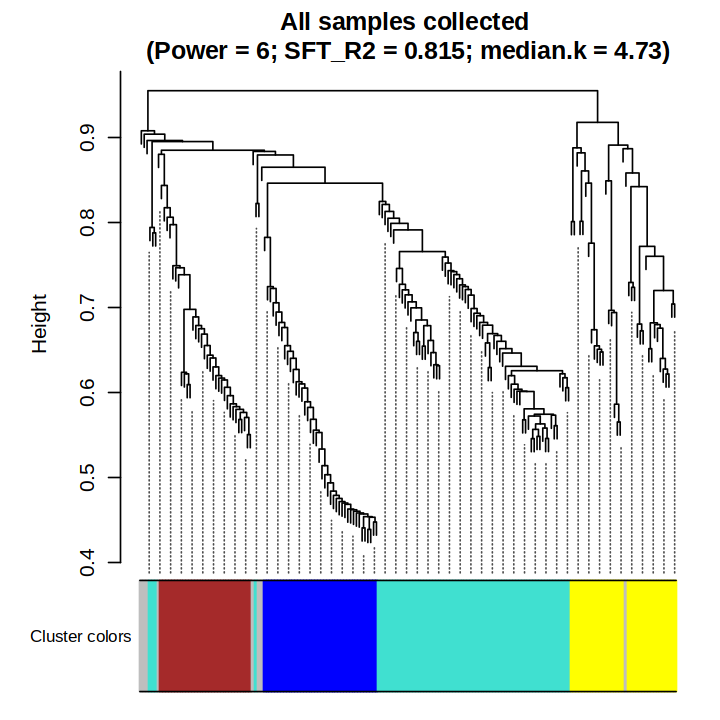

In [58]:
net = blockwiseModules(data_for_WGCNA, power = 6, networkType = "signed",
                        TOMType = "signed", minModuleSize = 19, # minModule = 10% of total
                        reassignThreshold = 0, mergeCutHeight = 0.25,
                        numericLabels = TRUE, pamRespectsDendro = FALSE,
                        verbose = 1)
# Convert labels to colors for plotting
mergedColors = labels2colors(net$colors)
to_brown  = which(mergedColors == "yellow")
to_yellow = which(mergedColors == "brown")
mergedColors[to_brown] = "brown"
mergedColors[to_yellow] = "yellow"

names(mergedColors) = names(net$colors)
# Plot the dendrogram and the module colors underneath
options(repr.plot.width = 6, repr.plot.height = 6)
plotDendroAndColors(net$dendrograms[[1]], mergedColors[net$blockGenes[[1]]],
                    main = "All samples collected \n(Power = 6; SFT_R2 = 0.815; median.k = 4.73)",
                    "Cluster colors",
                    dendroLabels = FALSE, hang = 0.03,
                    addGuide = TRUE, guideHang = 0.05)
# Calculate MEs with color labels
MEs0 = moduleEigengenes(data_for_WGCNA, mergedColors)$eigengenes
MEs = orderMEs(MEs0)
# cluster membership
datKME=signedKME(data_for_WGCNA, MEs, outputColumnName="MM_")
# Get cluster nodes
brown_4 = names(mergedColors[mergedColors == "brown"])
blue_4 = names(mergedColors[mergedColors == "blue"])
turquoise_4 = names(mergedColors[mergedColors == "turquoise"])
yellow_4 = names(mergedColors[mergedColors == "yellow"])

In [59]:
grep("320",brown_4)

[1] 14 18

TOM calculation: adjacency..
..will use 12 parallel threads.
 Fraction of slow calculations: 0.000000
..connectivity..
..matrix multiplication (system BLAS)..
..normalization..
..done.


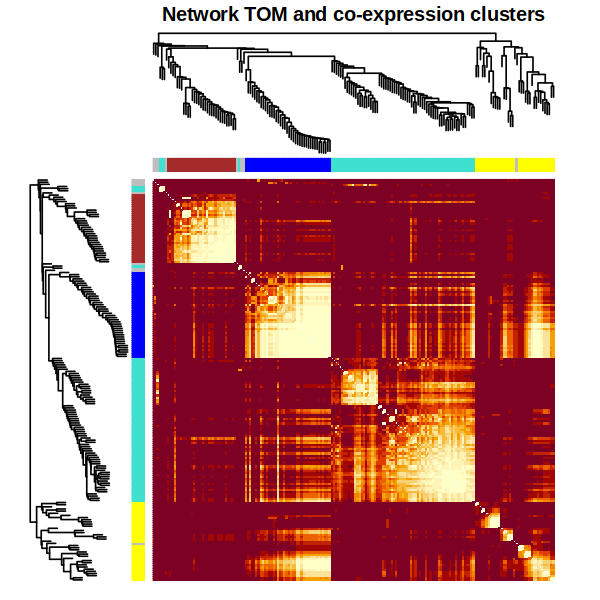

In [65]:
options(repr.plot.width = 5, repr.plot.height = 5)
diss1=1-TOMsimilarityFromExpr(data_for_WGCNA, power =6)
diag(diss1) = NA

# svg(filename = "Plots/Network_TOM_visualization_1.svg",width = 6,height = 6)
#pdf(file = "network_TOM_all_samples.pdf",width = 5,height = 5)

a = TOMplot(diss1^6, net$dendrograms[[1]], mergedColors,
        mergedColors,
        main = "Network TOM and co-expression clusters")
#dev.off()

In [66]:
print_prop = function(set){
    cat("Total size:",length(set),"\n")
    cat("miRNA: ",paste(length(grep("miR|let",set)),
               " (",length(grep("miR|let",set))/length(set),sep=""),")\n",sep="")
    cat("piRNA: ",paste(length(grep("piR",set)),
               " (",length(grep("piR",set))/length(set),sep=""),")\n",sep="")
    cat("tRNA: ",paste(length(grep("tR",set)),
               " (",length(grep("tR",set))/length(set),sep=""),")\n",sep="")
}

In [62]:
print_prop(brown_4)

Total size: 32 
miRNA: 18 (0.5625)
piRNA: 14 (0.4375)
tRNA: 0 (0)


In [63]:
colrs =c('hotpink3','steelblue','gold') # miRNA; piRNA; tRNA

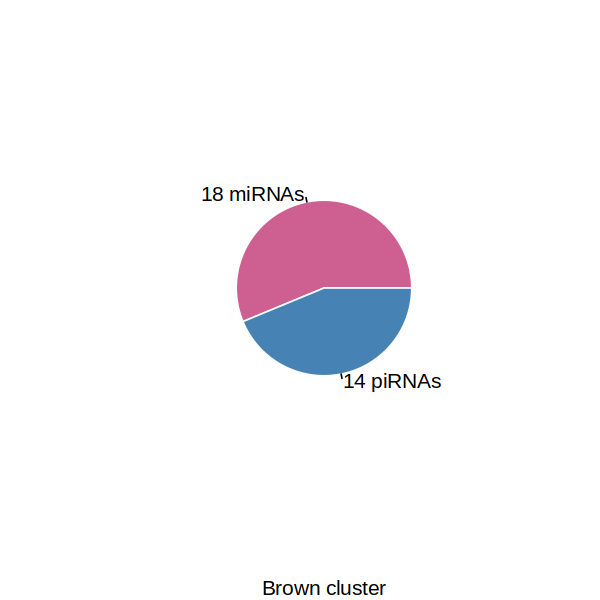

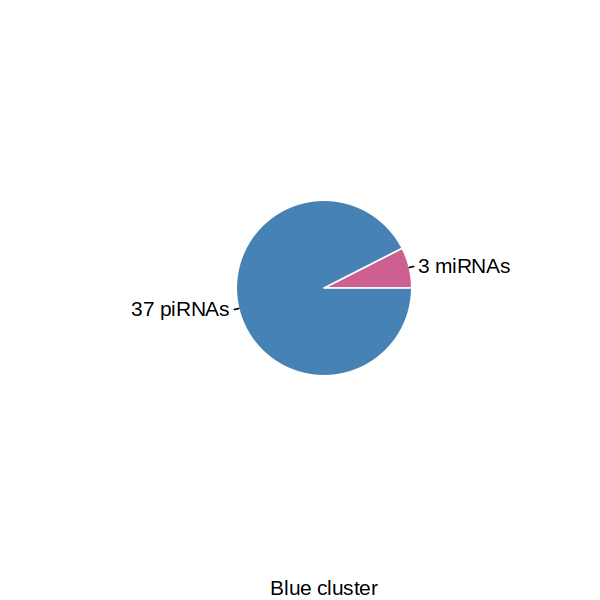

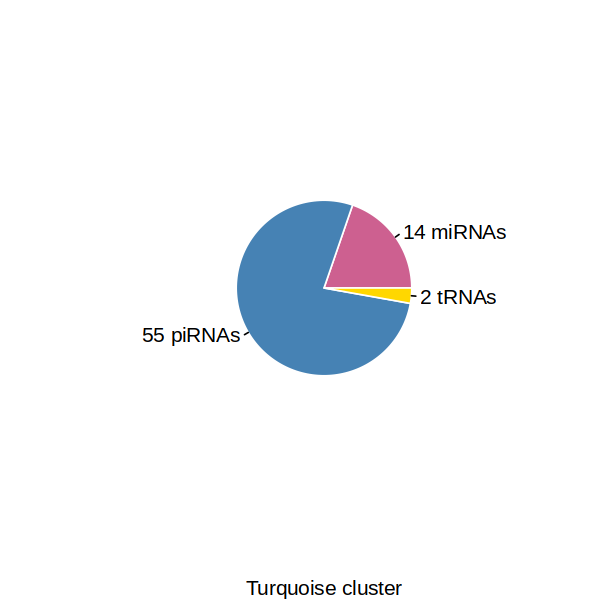

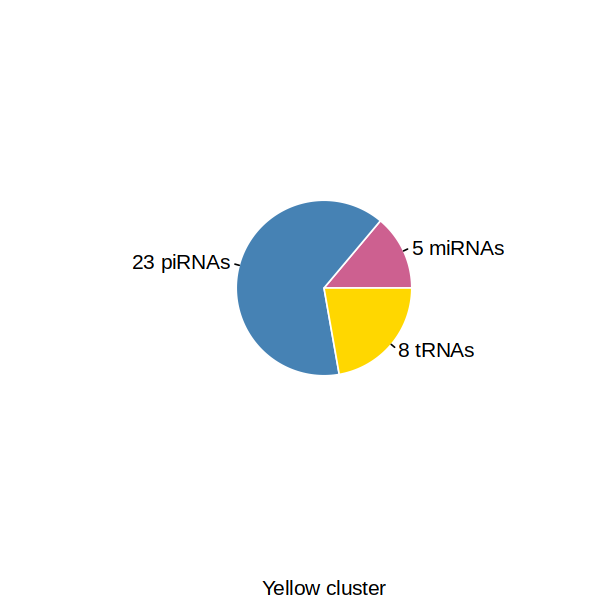

In [64]:
options(repr.plot.width = 5, repr.plot.height = 5)
#pdf(file = "brow_cluster_composition.pdf",width = 5,height = 5)
pie(c(18,14),labels =  c("18 miRNAs","14 piRNAs"),
    radius = 0.5, sub = "Brown cluster",
    border = "white", col=c('hotpink3','steelblue'))
#dev.off()
#pdf(file = "blue_cluster_composition.pdf",width = 5,height = 5)
pie(c(3,37),labels =  c("3 miRNAs","37 piRNAs"),
    radius = 0.5, sub = "Blue cluster",
    border = "white", col=c('hotpink3','steelblue'))
#dev.off()
#pdf(file = "turquoise_cluster_composition.pdf",width = 5,height = 5)
pie(c(14,55,2),labels =  c("14 miRNAs","55 piRNAs","2 tRNAs"),
    radius = 0.5, sub = "Turquoise cluster",
    border = "white", col=c('hotpink3','steelblue','gold'))
#dev.off()
#pdf(file = "yellow_cluster_composition.pdf",width = 5,height = 5)
pie(c(5,23,8),labels =  c("5 miRNAs","23 piRNAs","8 tRNAs"),
    radius = 0.5, sub = "Yellow cluster",
    border = "white", col=c('hotpink3','steelblue','gold'))
#dev.off()

In [71]:
grep("170413",brown_4,value=T)
grep("187041",brown_4,value=T)

grep("320a",brown_4,value=T)
grep("320b",brown_4,value=T)
grep("320b",brown_4,value=T)

[1] "piR-170413"

[1] "piR-187041"

[1] "miR-320a-3p"

[1] "miR-320b"

[1] "miR-320b"

In [72]:
# looking at the top 20 highest cluster membership nodes (kME) within each cluster
cat("BLUE\n")
datKME %>% arrange(desc(MM_blue)) %>% rownames() %>% head(,n=20)

BLUE


[1] "piR-6305852" "piR-6738734" "piR-720500"  "piR-3004347" "piR-2906214"
 [6] "piR-3416180" "piR-7025211" "piR-4957227" "piR-357703"  "piR-775507" 
[11] "piR-765768"  "piR-2663764" "piR-776281"  "piR-4642665" "piR-2649712"
[16] "piR-2626556" "piR-4290678" "miR-1247-3p" "piR-7720620" "miR-6090"

In [73]:
cat("BROWN\n")
datKME %>% arrange(desc(MM_brown)) %>% rownames() %>% head(,n=20) 

BROWN


[1] "miR-148a-3p" "piR-2866828" "miR-26b-5p"  "piR-148659"  "miR-375-3p" 
 [6] "miR-141-3p"  "miR-200a-3p" "piR-155056"  "miR-363-3p"  "piR-383453" 
[11] "miR-92a-3p"  "miR-429"     "piR-167717"  "miR-23b-3p"  "piR-168697" 
[16] "let-7c-5p"   "let-7a-5p"   "piR-187041"  "piR-73737"   "piR-170413"

In [ ]:
datKME %>% arrange(desc(MM_brown))

In [ ]:
cat("TURQUOISE\n")
datKME %>% arrange(desc(MM_turquoise)) %>% rownames() %>% head(,n=20)

In [ ]:
cat("YELLOW\n")
datKME %>% arrange(desc(MM_yellow)) %>% rownames() %>% head(,n=20)

In [74]:
datKME$class = 0 
datKME[grep("let|miR",rownames(datKME)),"class"] = "miRNA"
datKME[grep("tR",rownames(datKME)),"class"]      = "tRNA"
datKME[grep("piR",rownames(datKME)),"class"]     = "piRNA"
datKME$sncRNA = rownames(datKME)

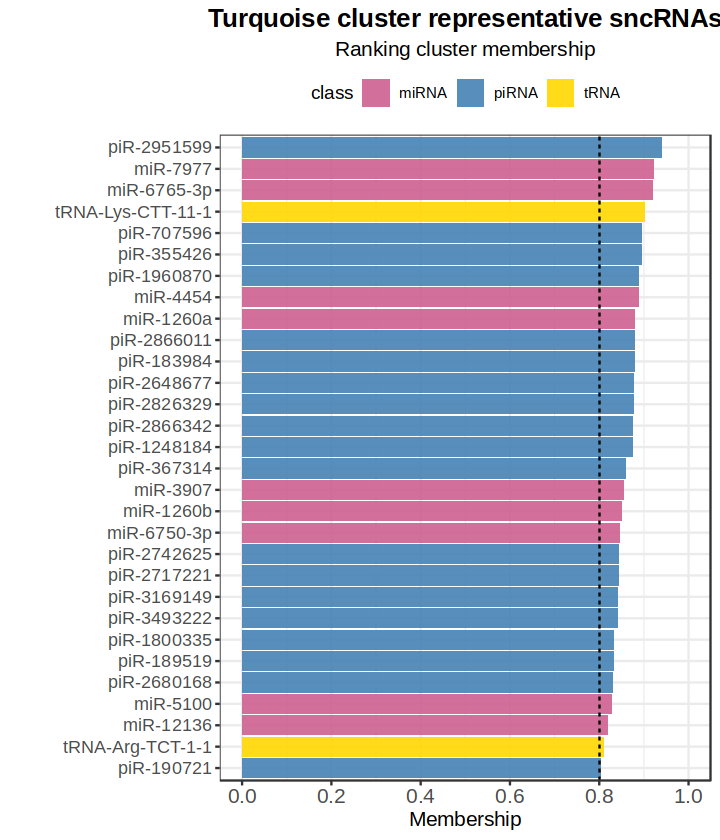

In [75]:
options(repr.plot.width = 6, repr.plot.height = 7)
plot1 = ggplot(datKME[!(datKME$MM_turquoise < 0.8),], aes(y = forcats::fct_reorder(sncRNA,MM_turquoise), 
                                     x = MM_turquoise, fill = class)) + geom_col(alpha=0.9) + 
ylab("") + xlab("Membership") +
ggtitle("Turquoise cluster representative sncRNAs", "Ranking cluster membership") + theme_bw() + 
theme(plot.title = element_text(hjust = 0.5, size = 15, face = "bold"),
      plot.subtitle = element_text(hjust = 0.5, size = 12),
        axis.title.x = element_text(size = 12),
        axis.text.y = element_text(size = 10.5),
        axis.text.x = element_text(size = 12),
        legend.position="top") +
        geom_vline(xintercept = 0.8,linetype="dashed") +
scale_x_continuous(limits = c(0, 1), breaks = seq(0,1,0.2)) +
scale_fill_manual(values=colrs)

#pdf(file = "ranking_representative_sncRNAs_turquoise.pdf",width = 6,height = 7)
plot1
#dev.off()

In [76]:
# create data.frame for statistical modeling
cluster_data =  data.frame(Subject = info[complete_PSS_2m_samples,]$Subject,
                           Batch = info[complete_PSS_2m_samples,]$Batch,
                           Visit = info[complete_PSS_2m_samples,]$Visit,
                           PSS = info[complete_PSS_2m_samples,]$PSS_Score,
                           PSS_delta_acute = info[complete_PSS_2m_samples,]$PSS_delta_acute,
                           PSS_2m_prior = info[complete_PSS_2m_samples,]$PSS_2m_prior,
                           PSS_delta_2m_delayed = info[complete_PSS_2m_samples,]$PSS_delta_2m_delayed,
                           ACE = info[complete_PSS_2m_samples,]$ACE,
                           Blue_activity = MEs$MEblue, 
                           Turquoise_activity = MEs$MEturquoise, 
                           Brown_activity = MEs$MEbrown, 
                           Yellow_activity = MEs$MEyellow)
rownames(cluster_data) = rownames(data_for_WGCNA)

##### Blue cluster model

,Estimate,Std. Error,t value
(Intercept),0.0073403622,0.0261664110,0.2805261
PSS_2m_prior,0.0001815587,0.0014255614,0.1273594
ACE,-0.0058716315,0.0059996530,-0.9786618
PSS_2m_prior:ACE,0.0001250314,0.0003394446,0.3683412


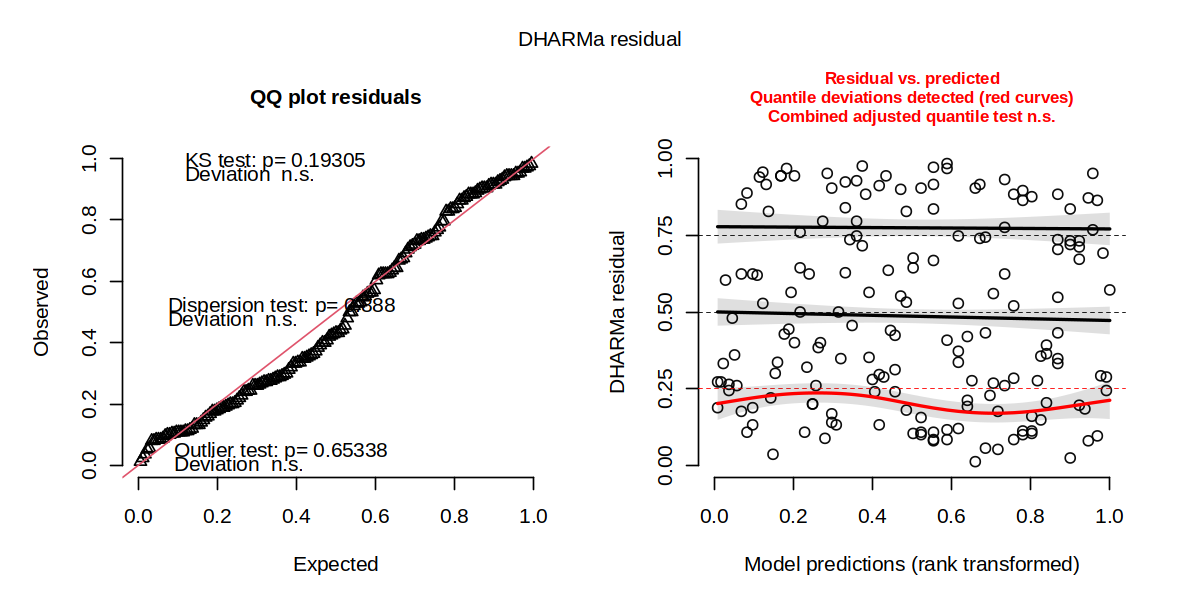

In [77]:
model_blue = lmer("Blue_activity ~ PSS_2m_prior + ACE + ACE:PSS_2m_prior + (1|Subject) + (1|Batch)",
                  cluster_data)
options(repr.plot.width = 10, repr.plot.height = 5)
# evaluating residual plot (DHARMa package)
temp = DHARMa::simulateResiduals(fittedModel = model_blue, plot = TRUE)
# checking effects
summary(model_blue)$coefficients

#sjPlot::tab_model(model_blue, show.re.var = FALSE,digits = 5,p.threshold = c(0.05, 0.01, 0.001))

##### Brown cluster model

,Estimate,Std. Error,t value
(Intercept),-0.0009297047,0.022598939,-0.04113931
PSS_delta_2m_delayed,0.0002947445,0.001049121,0.28094422
ACE,0.0009144188,0.004193478,0.21805737
PSS_delta_2m_delayed:ACE,-0.0001350842,0.000274168,-0.49270570


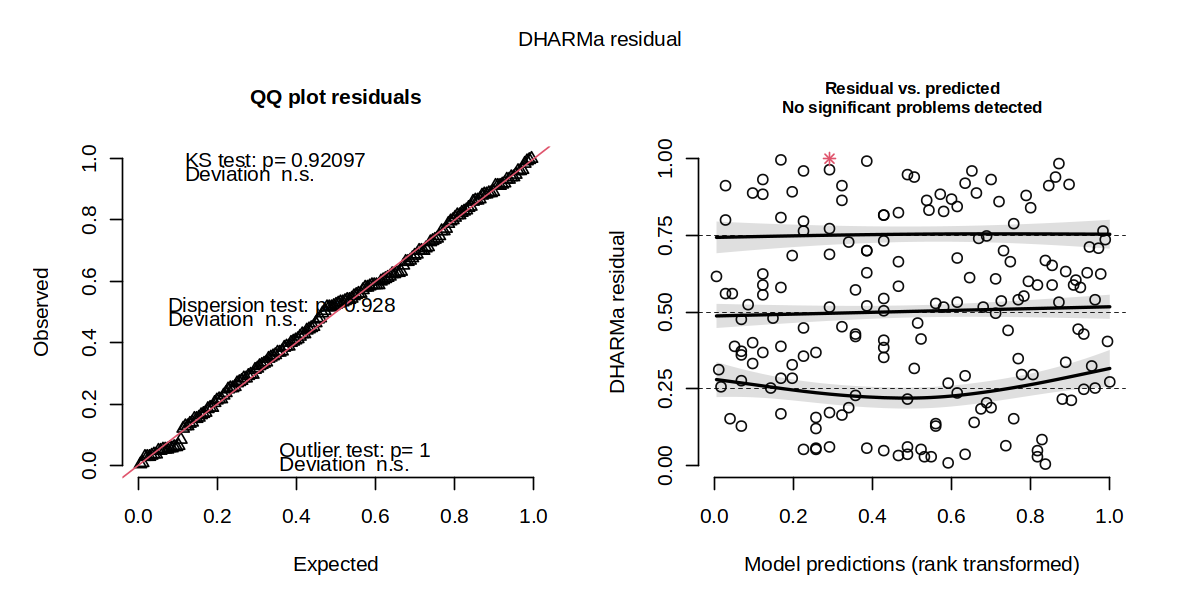

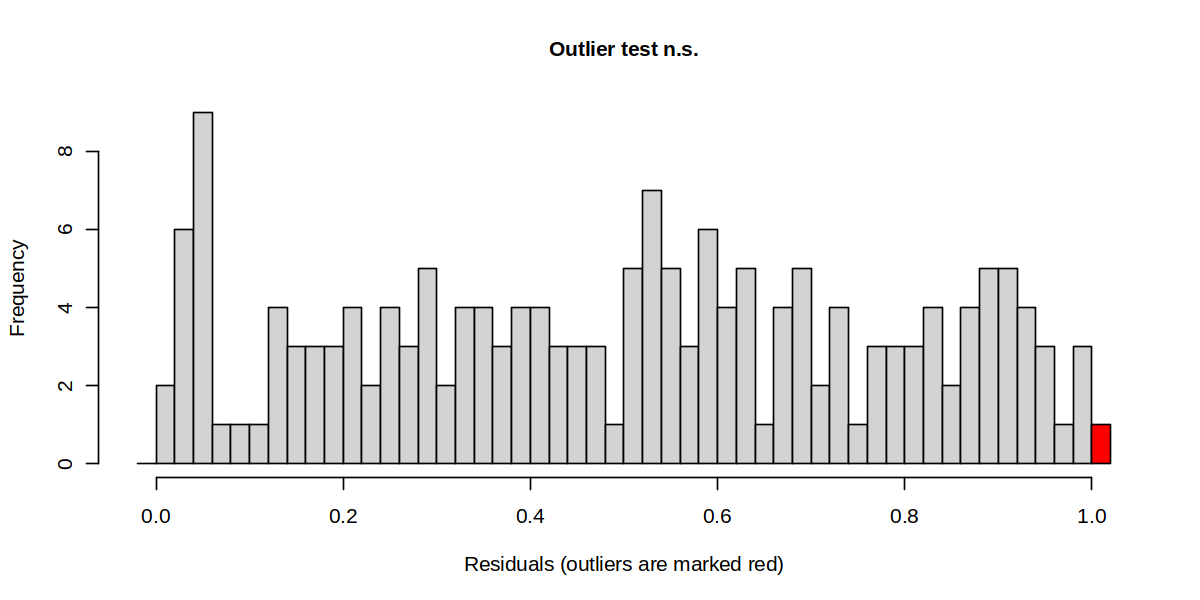

In [78]:
model_brown = lmer("Brown_activity ~ PSS_delta_2m_delayed + ACE + ACE:PSS_delta_2m_delayed + (1|Subject) + (1|Batch)",
                  cluster_data)
options(repr.plot.width = 10, repr.plot.height = 5)
# evaluating residual plot (DHARMa package)
temp = DHARMa::simulateResiduals(fittedModel = model_brown, plot = TRUE) ## OUTLIERS
# checking effects
summary(model_brown)$coefficients

outliers = DHARMa::testOutliers(temp) 
#sjPlot::tab_model(model_blue, show.re.var = FALSE,digits = 5,p.threshold = c(0.05, 0.01, 0.001))

##### Turquoise cluster model

,Estimate,Std. Error,t value
(Intercept),0.0478696253,0.0238961887,2.003233
PSS_2m_prior,-0.0034579886,0.0014637855,-2.362360
ACE,-0.0123317603,0.0062170703,-1.983532
PSS_2m_prior:ACE,0.0006619763,0.0003575882,1.851225


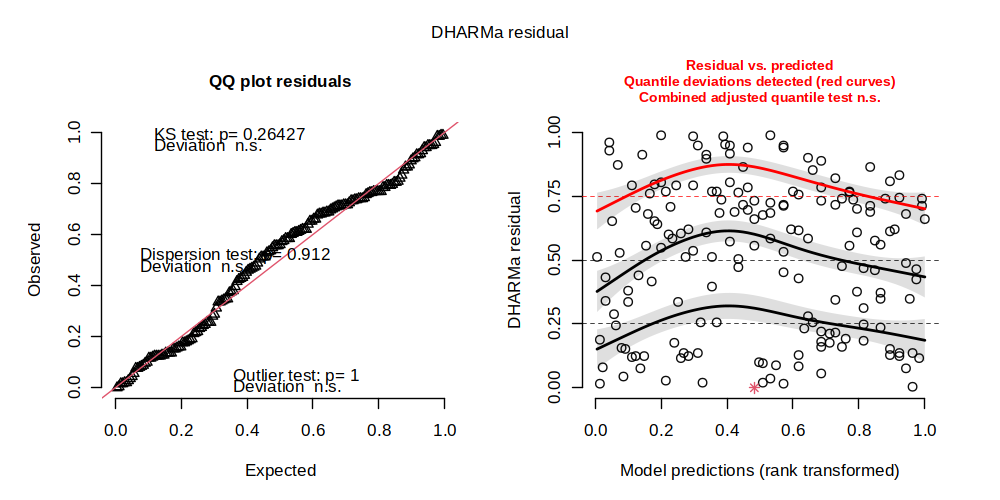

In [91]:
model_turquoise = lmer("Turquoise_activity ~ PSS_2m_prior*ACE  + (1|Subject) + (1|Batch)",
                  cluster_data)
options(repr.plot.width = 10, repr.plot.height = 5)
# evaluating residual plot (DHARMa package)
#pdf(file = "DHARMa_residual_simulation_linear_model.pdf",width = 10,height = 5)
temp = DHARMa::simulateResiduals(fittedModel = model_turquoise, plot = TRUE)
# dev.off()
# checking effects
summary(model_turquoise)$coefficients

sjPlot::tab_model(model_turquoise, show.re.var = FALSE, show.stat = TRUE,show.aic = TRUE,
                  digits = 4,p.threshold = c(0.05, 0.01, 0.001))

,Estimate,Std. Error,t value
(Intercept),0.0196466220,1.633531e-02,1.202709
I(PSS_2m_prior^2),-0.0001254560,5.258798e-05,-2.385640
I(ACE^2),-0.0020927538,7.519766e-04,-2.783004
PSS_2m_prior:ACE,0.0008231618,3.521393e-04,2.337603


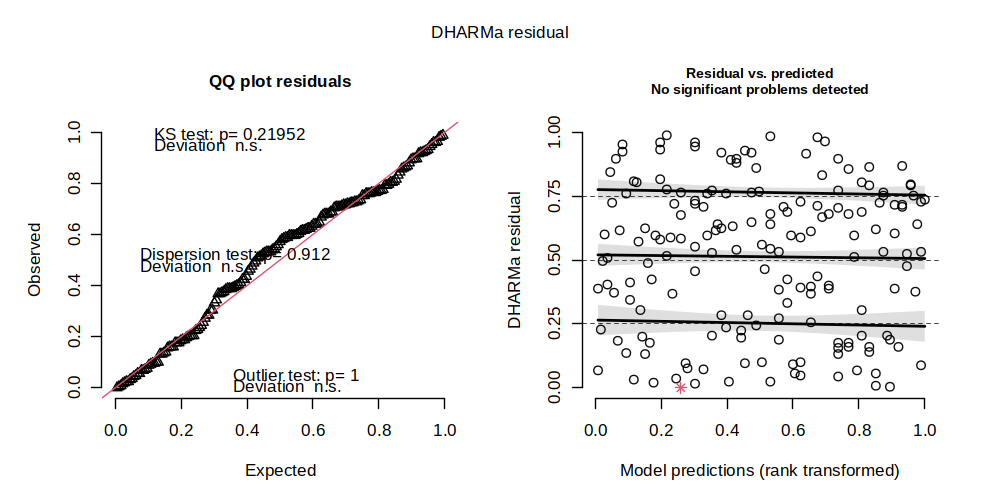

In [97]:
# attempt n.1 to address heteroskedasticity (perfect!)
model_turquoise_corrected = lmer("Turquoise_activity ~ I(PSS_2m_prior^2) + I(ACE^2) + PSS_2m_prior:ACE + (1|Subject) + (1|Batch)",
                                  cluster_data[])
options(repr.plot.width = 10, repr.plot.height = 5)
# evaluating residual plot (DHARMa package)
# pdf(file = "DHARMa_residual_simulation_quadratic_model.pdf",width = 10,height = 5)
temp = DHARMa::simulateResiduals(fittedModel = model_turquoise_corrected, plot = TRUE)
# dev.off()
# checking effects
summary(model_turquoise_corrected)$coefficients

options(browser="firefox")
sjPlot::tab_model(model_turquoise_corrected, show.stat = TRUE,show.aic = TRUE,
show.re.var = FALSE,digits = 4,p.threshold = c(0.05, 0.01, 0.001))
# Still need to apply p.adjust() using the p-value vector of all results from the models tested for all clusters

In [88]:
performance::compare_performance(model_turquoise,model_turquoise_corrected)

Name,Model,AIC,AIC_wt,AICc,AICc_wt,BIC,BIC_wt,R2_conditional,R2_marginal,ICC,RMSE,Sigma
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
model_turquoise,lmerMod,-428.1425,0.2174058,-427.4719,0.2174058,-405.9890,0.2174058,0.3401175,0.04634069,0.3080522,0.06047997,0.06388417
model_turquoise_corrected,lmerMod,-430.7042,0.7825942,-430.0336,0.7825942,-408.5507,0.7825942,0.3042037,0.06676173,0.2544281,0.06158771,0.06446611


In [81]:
# model_turquoise_corrected = lmer("Turquoise_activity ~ PSS_2m_prior + ACE + PSS_2m_prior:ACE + (1|Subject) + (1|Batch)",
#                                   cluster_data[cluster_data$Subject != "50107",])
# parameters::model_parameters(model_turquoise_corrected)[1:4,1:9]
# model_turquoise_corrected = lmer("Turquoise_activity ~ I(PSS_2m_prior^2) + I(ACE^2) + PSS_2m_prior:ACE + (1|Subject) + (1|Batch)",
#                                   cluster_data[cluster_data$Subject != "50107",])
# parameters::model_parameters(model_turquoise_corrected)[1:4,1:9]

Package 'merDeriv' needs to be installed to compute confidence intervals
  for random effect parameters.



,Parameter,Coefficient,SE,CI,CI_low,CI_high,t,df_error,p
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
1,(Intercept),0.0256358339,0.0238500243,0.95,-0.021461185,0.0727328534,1.0748766,162,0.2840283
2,PSS_2m_prior,-0.0022529782,0.0014356908,0.95,-0.005088059,0.0005821031,-1.5692642,162,0.1185376
3,ACE,0.0049519703,0.0080891135,0.95,-0.011021730,0.0209256704,0.6121771,162,0.5412788
4,PSS_2m_prior:ACE,-0.0001083739,0.0004516353,0.95,-0.001000225,0.0007834774,-0.2399589,162,0.8106655


Package 'merDeriv' needs to be installed to compute confidence intervals
  for random effect parameters.



,Parameter,Coefficient,SE,CI,CI_low,CI_high,t,df_error,p
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
1,(Intercept),1.521822e-02,1.712809e-02,0.95,-0.0186048840,4.904133e-02,0.88849509,162,0.3755918
2,I(PSS_2m_prior^2),-7.599727e-05,5.469538e-05,0.95,-0.0001840051,3.201056e-05,-1.38946417,162,0.1665984
3,I(ACE^2),6.173343e-04,1.393310e-03,0.95,-0.0021340559,3.368725e-03,0.44307049,162,0.6583058
4,PSS_2m_prior:ACE,-3.078804e-05,4.884166e-04,0.95,-0.0009952720,9.336959e-04,-0.06303643,162,0.9498152


Warning message in is.na(xlab):
“is.na() applied to non-(list or vector) of type 'expression'”
Warning message in is.na(xlab):
“is.na() applied to non-(list or vector) of type 'expression'”


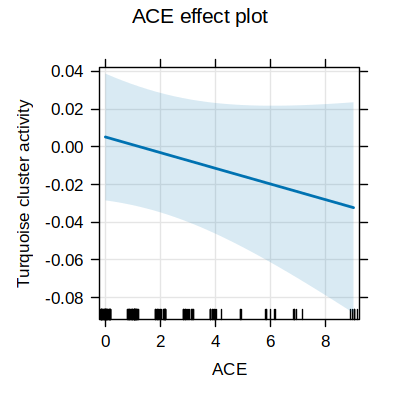

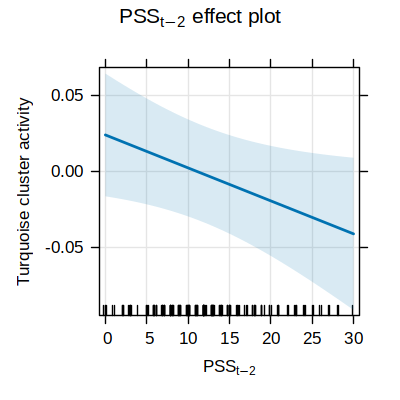

In [92]:
options(repr.plot.width = 4, repr.plot.height = 4,repr.plot.res = 100)

# pdf(file = "turquoise_ACE_effect_linear.pdf",width = 4,height = 4)
plot(effects::Effect("ACE", model_turquoise,
                     xlevels=list(ACE=seq(0, 9, 1))), 
     main = expression("ACE effect plot"), lwd=2,
     ylab = "Turquoise cluster activity",
     xlab = expression("ACE"),grid=TRUE)
# dev.off()

# pdf(file = "turquoise_PSS_effect_linear.pdf",width = 4,height = 4)
plot(effects::Effect("PSS_2m_prior", model_turquoise,
                     xlevels=list(PSS_2m_prior=seq(0, 30, 1))), 
     main = expression("PSS"[t-2]~"effect plot"), lwd=2,
     ylab = "Turquoise cluster activity",
     xlab = expression("PSS"[t-2]),grid=TRUE)
# dev.off()


Warning message in is.na(xlab):
“is.na() applied to non-(list or vector) of type 'expression'”
Warning message in is.na(xlab):
“is.na() applied to non-(list or vector) of type 'expression'”


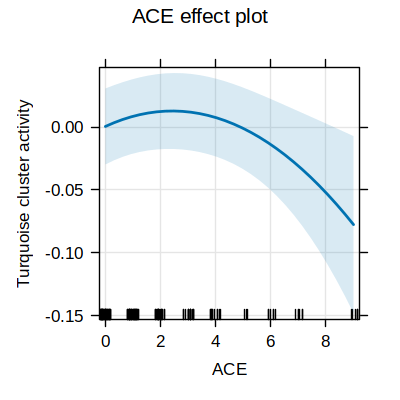

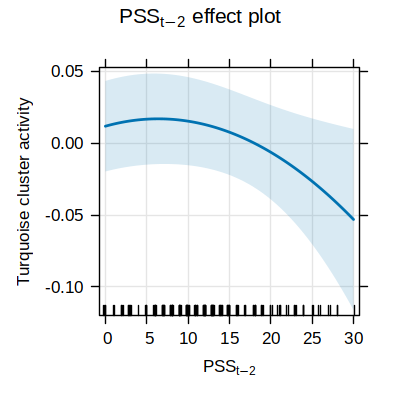

In [86]:
options(repr.plot.width = 4, repr.plot.height = 4,repr.plot.res = 100)

# pdf(file = "turquoise_ACE_effect.pdf",width = 4,height = 4)
plot(effects::Effect("ACE", model_turquoise_corrected,
                     xlevels=list(ACE=seq(0, 9, 1))), 
     main = expression("ACE effect plot"), lwd=2,
     ylab = "Turquoise cluster activity",
     xlab = expression("ACE"),grid=TRUE)
# dev.off()

# pdf(file = "turquoise_PSS_effect.pdf",width = 4,height = 4)
plot(effects::Effect("PSS_2m_prior", model_turquoise_corrected,
                     xlevels=list(PSS_2m_prior=seq(0, 30, 1))), 
     main = expression("PSS"[t-2]~"effect plot"), lwd=2,
     ylab = "Turquoise cluster activity",
     xlab = expression("PSS"[t-2]),grid=TRUE)
# dev.off()


,Estimate,Std. Error,t value
(Intercept),0.0094812600,0.0163789184,0.5788697
PSS_delta_2m_delayed,-0.0027869140,0.0015678949,-1.7774877
ACE,-0.0045625111,0.0030220636,-1.5097337
PSS_delta_2m_delayed:ACE,0.0009320253,0.0004085471,2.2813167


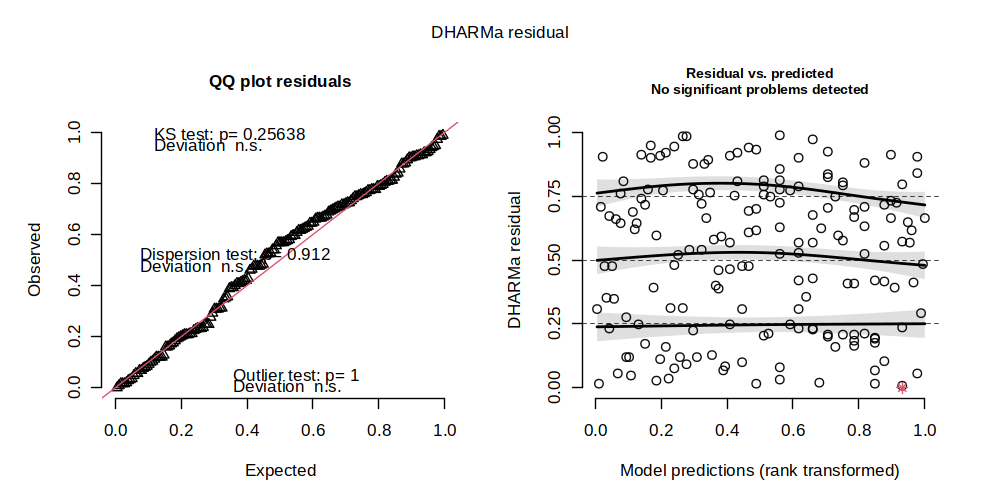

In [95]:
# delta PSS 2 months before
model_turquoise = lmer("Turquoise_activity ~ PSS_delta_2m_delayed + ACE + PSS_delta_2m_delayed:ACE + (1|Subject) + (1|Batch)",
                                  cluster_data)
options(repr.plot.width = 10, repr.plot.height = 5)
# evaluating residual plot (DHARMa package)
temp = DHARMa::simulateResiduals(fittedModel = model_turquoise, plot = TRUE)
# checking effects
summary(model_turquoise)$coefficients

options(browser="firefox")
sjPlot::tab_model(model_turquoise, show.re.var = FALSE, digits = 5,p.threshold = c(0.05, 0.01, 0.001))
# Still need to apply p.adjust() using the p-value vector of all results from the models tested for all clusters

##### Yellow cluster model

,Estimate,Std. Error,t value
(Intercept),-0.0147743408,0.0265003125,-0.5575157
PSS_2m_prior,0.0011404401,0.0012433853,0.9172057
ACE,0.0063924399,0.0058618498,1.0905158
PSS_2m_prior:ACE,-0.0003725261,0.0002712944,-1.3731430


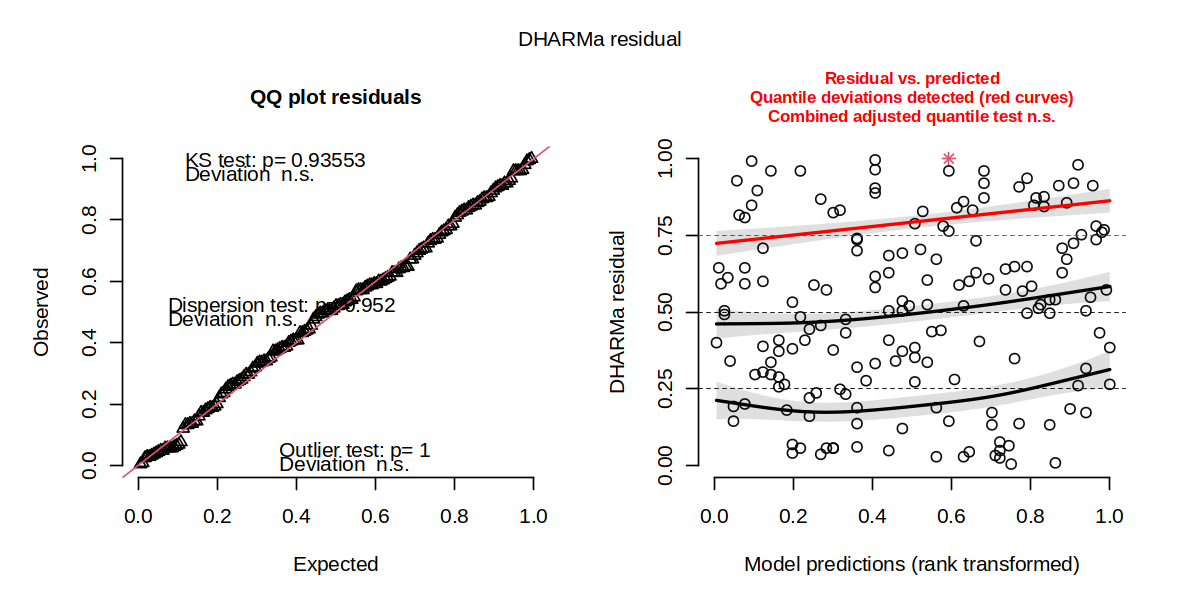

In [98]:
model_yellow = lmer("Yellow_activity ~ PSS_2m_prior + ACE + ACE:PSS_2m_prior + (1|Subject) + (1|Batch)",
                  cluster_data)
options(repr.plot.width = 10, repr.plot.height = 5)
# evaluating residual plot (DHARMa package)
temp = DHARMa::simulateResiduals(fittedModel = model_yellow, plot = TRUE)
# checking effects
summary(model_yellow)$coefficients

#sjPlot::tab_model(model_yellow, show.re.var = FALSE,digits = 5,p.threshold = c(0.05, 0.01, 0.001))

### Session Info

In [ ]:
### Session info
sessionInfo()